# Resumen final: modelos de aptitud solar fotovoltaica

Jesús David Arévalo Montilla, Enmanuel David Díaz Molinares y Alex David Terán Meza (Universidad del Norte, Pregrado en Ciencia de Datos). Machine Learning, profesor Dr. Lihki Rubio, octubre de 2026.

Este cuaderno junta los resultados del experimento de 140 combinaciones sobre el índice de aptitud solar de Mantilla-Guerra et al. (2026): 112 de clasificación en tres clases y 28 de regresión del índice continuo. Se corren 136, porque KNN no admite `class_weight`. Son siete modelos, cuatro esquemas de balanceo y cuatro optimizadores, evaluados con validación anidada y bloques espaciales de 5° × 5°.

También vuelve sobre los límites del índice, que sale solo del terreno, y lo contrasta con datos reales de generación: 16 plantas solares colombianas del operador XM y 8,589 días planta con clima de Open-Meteo. Además cubre la calibración de las probabilidades, el costo computacional, las pruebas estadísticas entre modelos y la interpretación con TreeSHAP y LIME. Los detalles de cada parte están en los cuadernos `Experimento_1_Diseno.ipynb` a `Experimento_7_Interpretabilidad.ipynb`.

In [1]:
import sys
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display, Markdown

# Configuración de rutas del proyecto
PROCESO_DIR = Path.cwd()
if not (PROCESO_DIR / "src").exists():
    for candidate in [PROCESO_DIR, PROCESO_DIR.parent, PROCESO_DIR / "ml presentación" / "proceso"]:
        if (candidate / "src").exists():
            PROCESO_DIR = candidate
            break

sys.path.insert(0, str(PROCESO_DIR))
import src.config as config
import src.analisis as analisis
import src.stats as stats

# Carga de la tabla maestra con las combinaciones evaluadas en 5 outer folds
maestra, res = analisis.cargar(incluir_halving=False)
print(f"Tabla maestra cargada exitosamente: {len(maestra)} ejecuciones de outer folds.")
print(f"Combinaciones consolidadas: {len(res)} (Clasificación: {(res.tarea=='clf').sum()}, Regresión: {(res.tarea=='reg').sum()}).")

Tabla maestra cargada exitosamente: 680 ejecuciones de pliegues externos.
Combinaciones consolidadas: 136 (Clasificación: 108, Regresión: 28).


## 1. Diseño del experimento (Cuadro 1)

Cada modelo se cruza con los esquemas de balanceo y los optimizadores: 112 combinaciones en clasificación (7 × 4 × 4) y 28 en regresión (7 × 4). De las de clasificación, 4 no aplican (KNN con `class_weight`).

La validación es anidada y espacial (Roberts et al., 2017; Cawley y Talbot, 2010). El bucle externo tiene 5 pliegues por bloques geográficos y mide el desempeño en bloques que el modelo no vio, para que no haya fuga espacial. El bucle interno tiene 3 pliegues, también por bloques, y elige los hiperparámetros dentro del entrenamiento externo.

In [2]:
# Cuadro 1: Desglose aritmético de la explosión combinatoria del pipeline
cuadro_1_data = {
    "Task": ["Clasificación", "Regresión", "Total General"],
    "Modelos Base (m)": [7, 7, 14],
    "Balanceo (Oversampling)": [4, 1, "-"],
    "Optimizadores (o)": [4, 4, 4],
    "Operación": ["7 × 4 × 4", "7 × 1 × 4", "112 + 28"],
    "Combinaciones Únicas": [112, 28, 140],
    "Outer Folds": [5, 5, 5],
    "Modelos Entrenados (Total)": [560, 140, 700]
}
cuadro_1 = pd.DataFrame(cuadro_1_data)
display(cuadro_1.style.set_caption("Cuadro 1: Desglose de combinaciones en el pipeline experimental").hide(axis='index'))

Task,Modelos Base (m),Balanceo (Oversampling),Optimizadores (o),Operación,Combinaciones Únicas,Outer Folds,Modelos Entrenados (Total)
Clasificación,7,4,4,7 × 4 × 4,112,5,560
Regresión,7,1,4,7 × 1 × 4,28,5,140
Total General,14,-,4,112 + 28,140,5,700


## 2. Espacios de búsqueda (Cuadro 2)

El cuadro lista los hiperparámetros de cada modelo y sus rangos de búsqueda. Los rangos exactos, con su fuente, están en `Experimento_1_Diseno.ipynb`.

In [3]:
# Cuadro 2: Espacios de búsqueda e hiperparámetros por modelo
cuadro_2_data = [
    {"Tarea": "Clasificación", "Modelo": "KNN", "Hiperparámetros Principales": "n_neighbors (3–50), weights, metric", "Espacio / Distribución": "k ∈ [3, 50], weights ∈ {uniform, distance}, metric ∈ {euclidean, manhattan}"},
    {"Tarea": "Clasificación", "Modelo": "Naive Bayes", "Hiperparámetros Principales": "var_smoothing", "Espacio / Distribución": "log-uniforme [1e-11, 1e-7]"},
    {"Tarea": "Clasificación", "Modelo": "Regresión Logística", "Hiperparámetros Principales": "C, penalty, solver", "Espacio / Distribución": "C ∈ log-uniforme [1e-3, 1e2], penalty ∈ {l1, l2}, solver ∈ {saga, liblinear}"},
    {"Tarea": "Clasificación", "Modelo": "Árbol de Decisión", "Hiperparámetros Principales": "max_depth, min_samples_split, criterion", "Espacio / Distribución": "depth ∈ [3, 20], split ∈ [2, 20], criterion ∈ {gini, entropy}"},
    {"Tarea": "Clasificación", "Modelo": "Random Forest", "Hiperparámetros Principales": "n_estimators, max_depth, max_features", "Espacio / Distribución": "n_est ∈ [50, 300], depth ∈ [5, 25], features ∈ {sqrt, log2}"},
    {"Tarea": "Clasificación", "Modelo": "XGBoost", "Hiperparámetros Principales": "n_estimators, learning_rate, max_depth, subsample", "Espacio / Distribución": "n_est ∈ [50, 300], lr ∈ [0.01, 0.3], depth ∈ [3, 10], subsample ∈ [0.6, 1.0]"},
    {"Tarea": "Clasificación", "Modelo": "SVM RBF", "Hiperparámetros Principales": "C, gamma", "Espacio / Distribución": "C ∈ log-uniforme [1e-2, 1e2], gamma ∈ {scale, auto, log-uniforme [1e-3, 1]}"},
    {"Tarea": "Regresión", "Modelo": "KNN", "Hiperparámetros Principales": "n_neighbors, weights, metric", "Espacio / Distribución": "k ∈ [3, 50], weights ∈ {uniform, distance}, metric ∈ {euclidean, manhattan}"},
    {"Tarea": "Regresión", "Modelo": "Ridge", "Hiperparámetros Principales": "alpha", "Espacio / Distribución": "alpha ∈ log-uniforme [1e-3, 1e3]"},
    {"Tarea": "Regresión", "Modelo": "Lasso", "Hiperparámetros Principales": "alpha", "Espacio / Distribución": "alpha ∈ log-uniforme [1e-4, 1e1]"},
    {"Tarea": "Regresión", "Modelo": "Árbol de Decisión", "Hiperparámetros Principales": "max_depth, min_samples_split, criterion", "Espacio / Distribución": "depth ∈ [3, 20], split ∈ [2, 20], criterion ∈ {squared_error, friedman_mse}"},
    {"Tarea": "Regresión", "Modelo": "Random Forest", "Hiperparámetros Principales": "n_estimators, max_depth, max_features", "Espacio / Distribución": "n_est ∈ [50, 300], depth ∈ [5, 25], features ∈ {sqrt, 1.0}"},
    {"Tarea": "Regresión", "Modelo": "XGBoost", "Hiperparámetros Principales": "n_estimators, learning_rate, max_depth, subsample", "Espacio / Distribución": "n_est ∈ [50, 300], lr ∈ [0.01, 0.3], depth ∈ [3, 10], colsample ∈ [0.6, 1.0]"},
    {"Tarea": "Regresión", "Modelo": "SVR RBF", "Hiperparámetros Principales": "C, epsilon, gamma", "Espacio / Distribución": "C ∈ log-uniforme [1e-2, 1e2], epsilon ∈ [0.01, 0.5], gamma ∈ {scale, auto}"}
]
cuadro_2 = pd.DataFrame(cuadro_2_data)
display(cuadro_2.style.set_caption("Cuadro 2: Espacios de búsqueda e hiperparámetros explorados por modelo").hide(axis='index'))

Tarea,Modelo,Hiperparámetros Principales,Espacio / Distribución
Clasificación,KNN,"n_neighbors (3–50), weights, metric","k ∈ [3, 50], weights ∈ {uniform, distance}, metric ∈ {euclidean, manhattan}"
Clasificación,Naive Bayes,var_smoothing,"log-uniforme [1e-11, 1e-7]"
Clasificación,Regresión Logística,"C, penalty, solver","C ∈ log-uniforme [1e-3, 1e2], penalty ∈ {l1, l2}, solver ∈ {saga, liblinear}"
Clasificación,Árbol de Decisión,"max_depth, min_samples_split, criterion","depth ∈ [3, 20], split ∈ [2, 20], criterion ∈ {gini, entropy}"
Clasificación,Random Forest,"n_estimators, max_depth, max_features","n_est ∈ [50, 300], depth ∈ [5, 25], features ∈ {sqrt, log2}"
Clasificación,XGBoost,"n_estimators, learning_rate, max_depth, subsample","n_est ∈ [50, 300], lr ∈ [0.01, 0.3], depth ∈ [3, 10], subsample ∈ [0.6, 1.0]"
Clasificación,SVM RBF,"C, gamma","C ∈ log-uniforme [1e-2, 1e2], gamma ∈ {scale, auto, log-uniforme [1e-3, 1]}"
Regresión,KNN,"n_neighbors, weights, metric","k ∈ [3, 50], weights ∈ {uniform, distance}, metric ∈ {euclidean, manhattan}"
Regresión,Ridge,alpha,"alpha ∈ log-uniforme [1e-3, 1e3]"
Regresión,Lasso,alpha,"alpha ∈ log-uniforme [1e-4, 1e1]"


## 3. Balanceo y calibración (Cuadro 3)

La clase minoritaria (Baja) representa el 3.1 % frente a Media (22.0 %) y Alta (74.8 %).

En los ensambles de árboles (Random Forest y XGBoost), SMOTE y ADASYN no mejoran el F1 macro y empeoran la calibración. El ECE de Random Forest pasa de 0.016 sin balanceo a 0.027 con ADASYN y 0.030 con SMOTE, y el de XGBoost de 0.017 a 0.020 y 0.033. En cambio sí suben el recall de la clase Baja, como se ve en `Experimento_2_Clasificacion.ipynb`.

Técnica de Balanceo,F1-Macro Promedio,Recall Clase Baja,Exactitud Balanceada,Brier Score,ECE
adasyn,0.7293 ± 0.1435,0.8805 ± 0.0851,0.8161 ± 0.0707,0.1011 ± 0.0605,0.1063 ± 0.0825
class_weight,0.7499 ± 0.1575,0.8935 ± 0.0646,0.8297 ± 0.0728,0.0911 ± 0.0651,0.0841 ± 0.0807
ninguno,0.7779 ± 0.1264,0.7278 ± 0.1497,0.7724 ± 0.1130,0.0634 ± 0.0341,0.0334 ± 0.0229
smote,0.7542 ± 0.1446,0.8932 ± 0.0721,0.8319 ± 0.0715,0.0913 ± 0.0617,0.0876 ± 0.0792


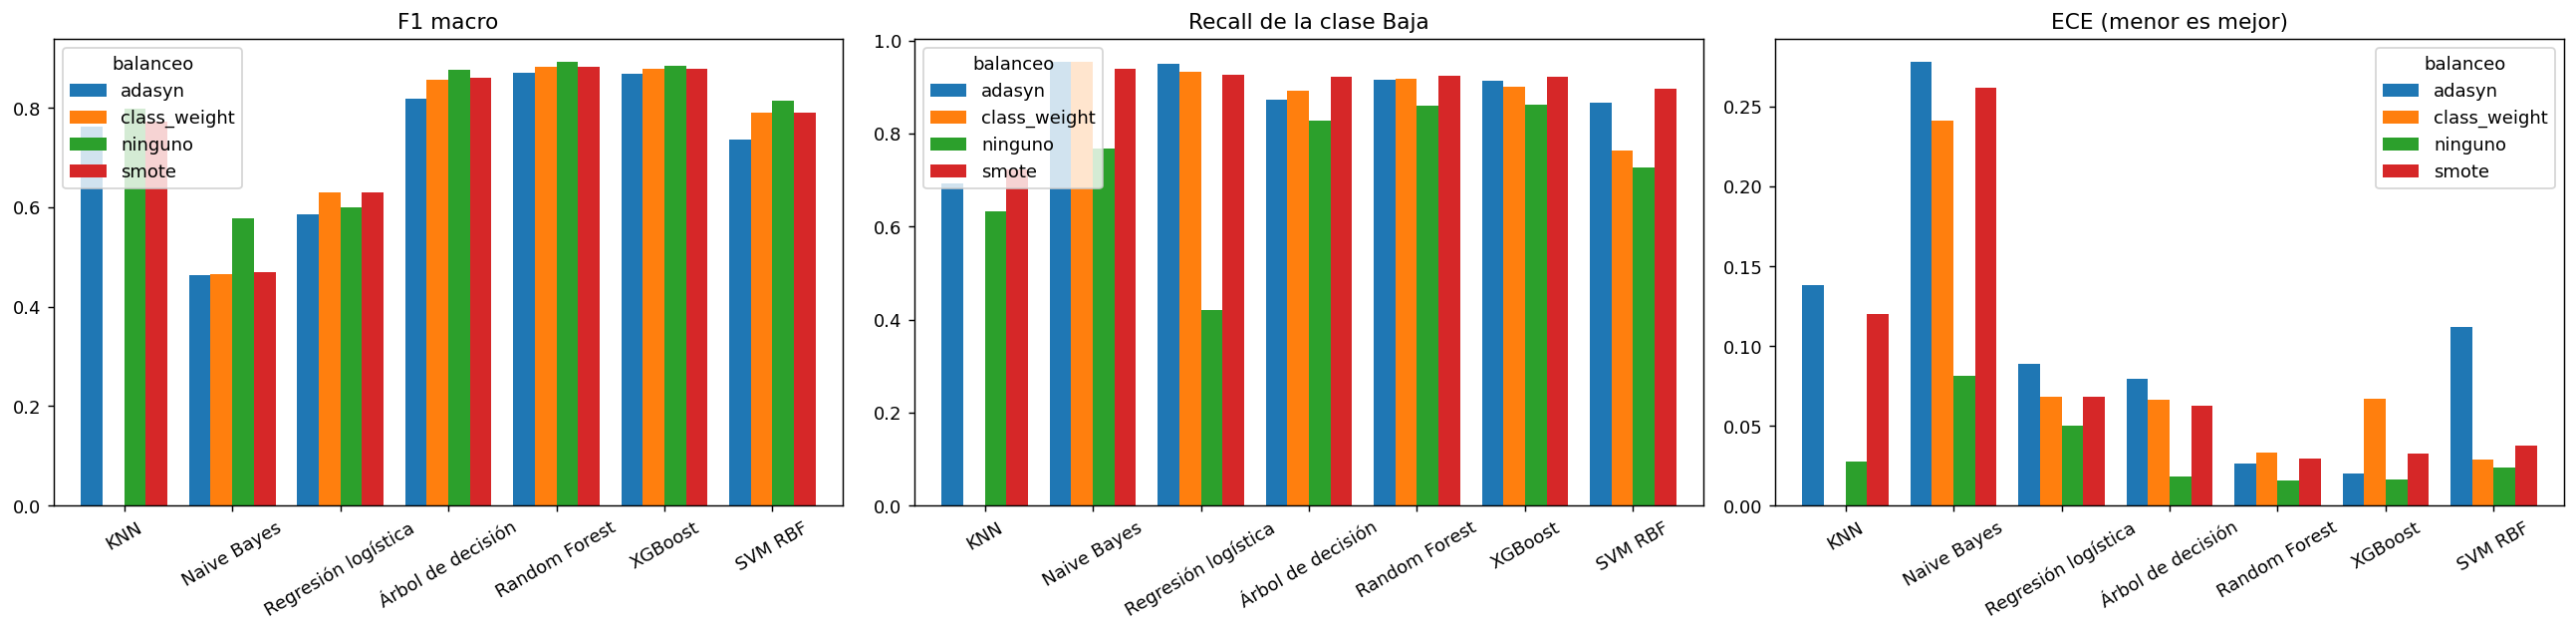

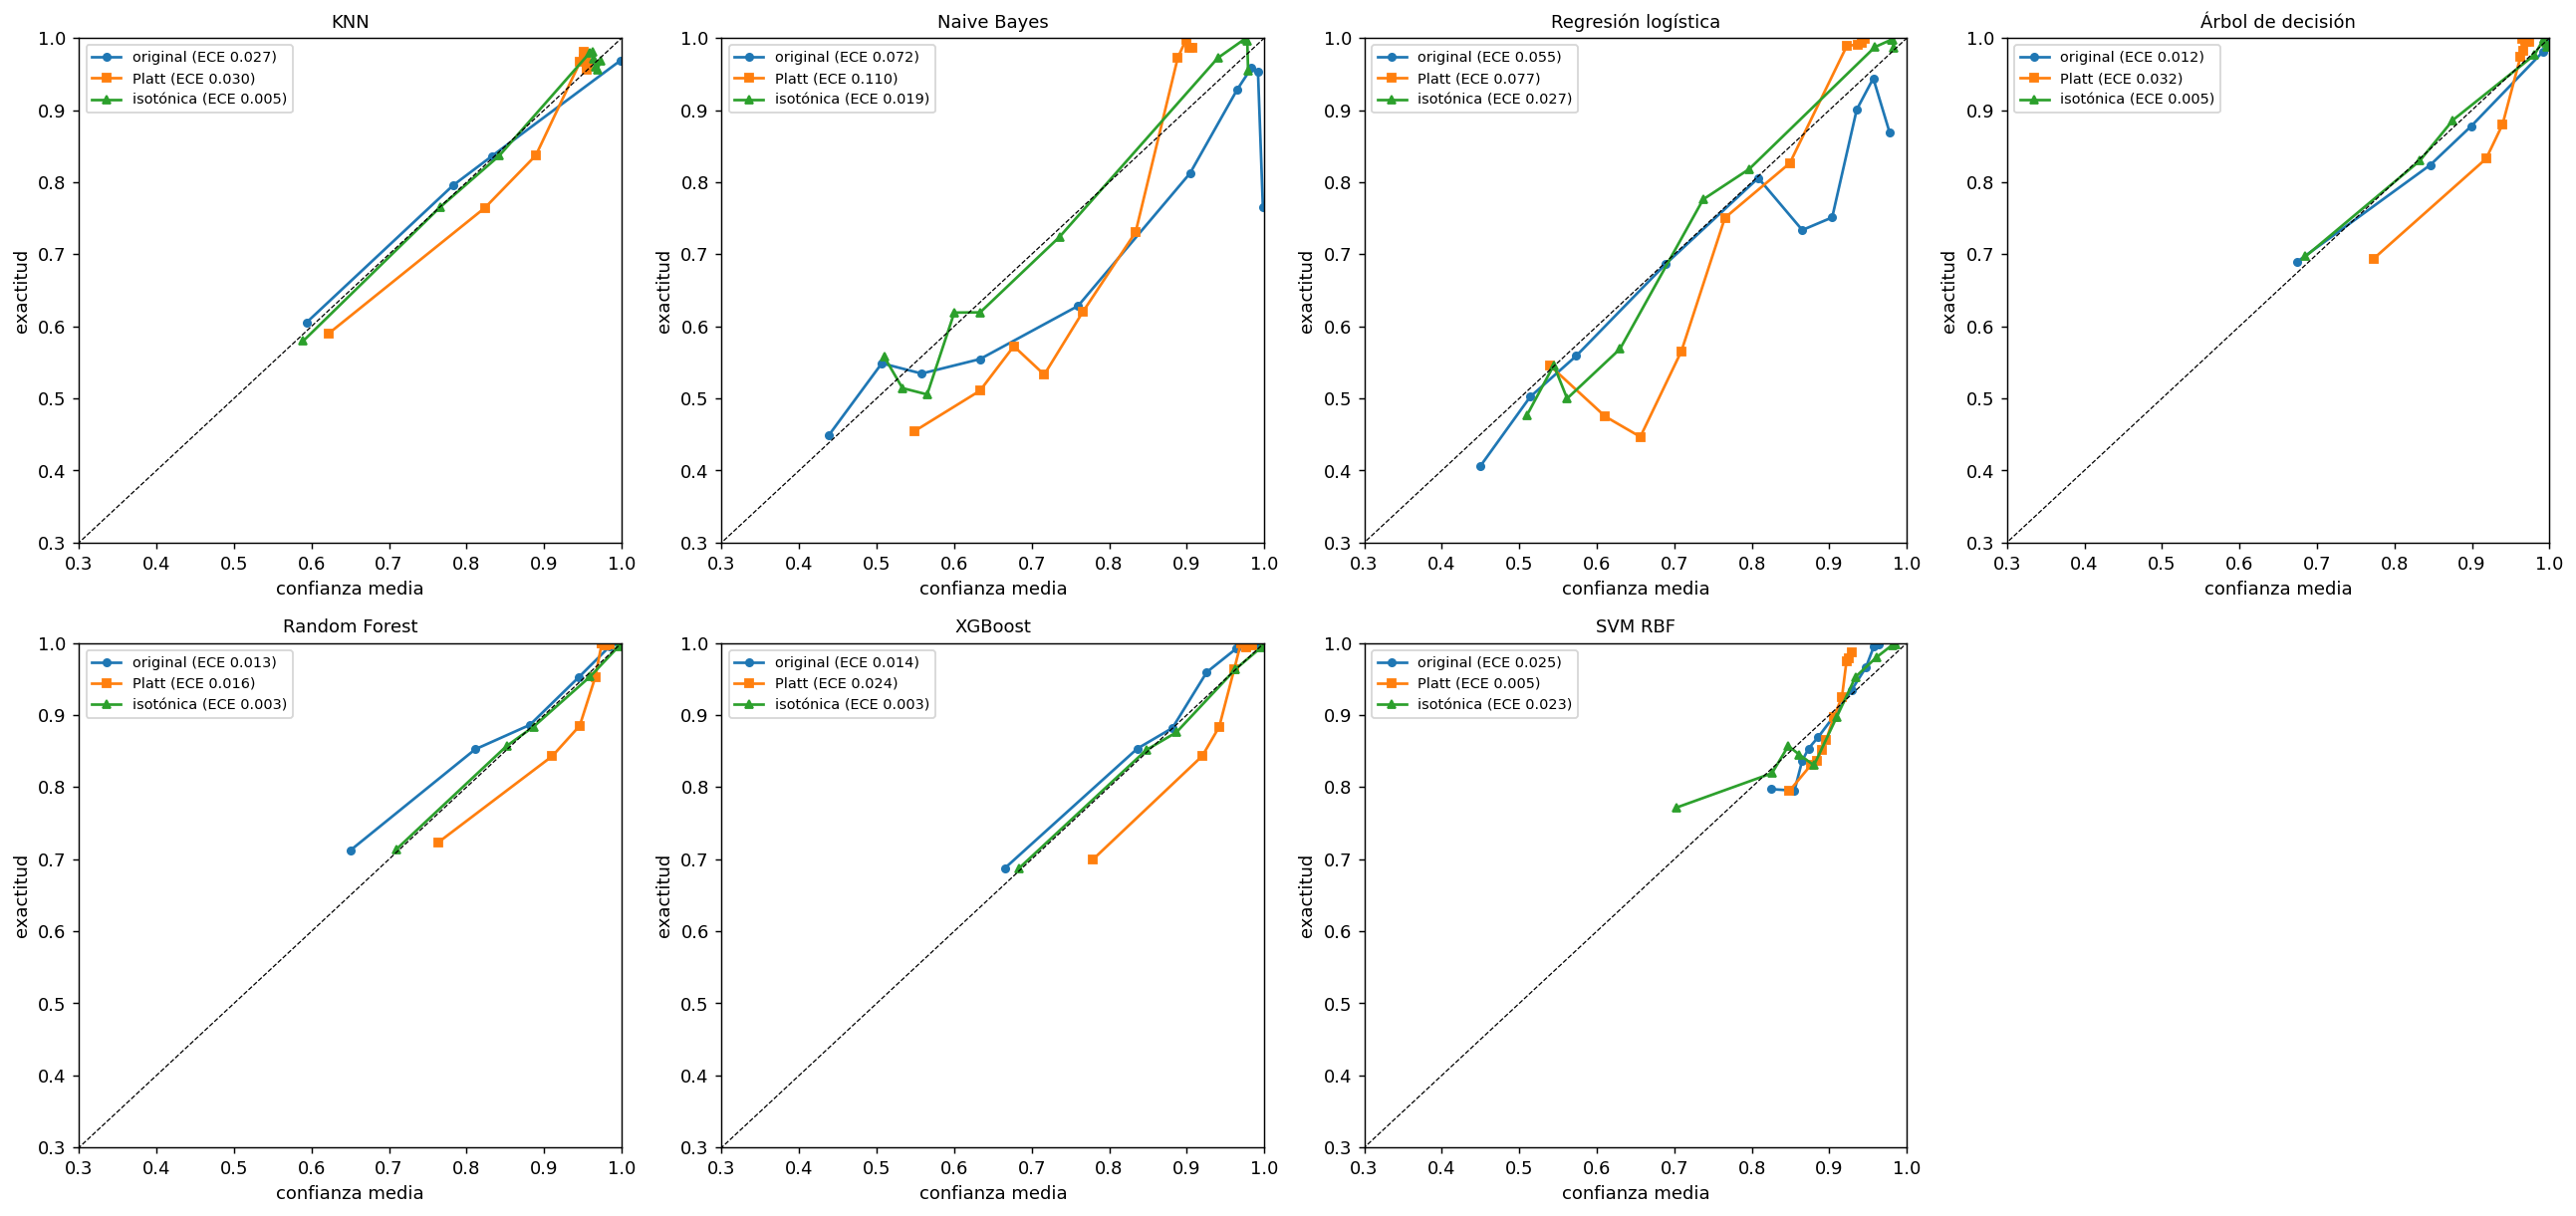

In [4]:
# Cuadro 3: Comparación de técnicas de balanceo en clasificación
res_clf = res[res.tarea == "clf"]
bal_grp = res_clf.groupby("balanceo").agg({
    "f1_macro": ["mean", "std"],
    "recall_baja": ["mean", "std"],
    "exactitud_bal": ["mean", "std"],
    "brier": ["mean", "std"],
    "ece": ["mean", "std"]
}).round(4)

bal_grp.columns = [f"{c[0]}_{c[1]}" for c in bal_grp.columns]
cuadro_3 = pd.DataFrame({
    "Técnica de Balanceo": bal_grp.index,
    "F1-Macro Promedio": [f"{m:.4f} ± {s:.4f}" for m, s in zip(bal_grp["f1_macro_mean"], bal_grp["f1_macro_std"])],
    "Recall Clase Baja": [f"{m:.4f} ± {s:.4f}" for m, s in zip(bal_grp["recall_baja_mean"], bal_grp["recall_baja_std"])],
    "Exactitud Balanceada": [f"{m:.4f} ± {s:.4f}" for m, s in zip(bal_grp["exactitud_bal_mean"], bal_grp["exactitud_bal_std"])],
    "Brier Score": [f"{m:.4f} ± {s:.4f}" for m, s in zip(bal_grp["brier_mean"], bal_grp["brier_std"])],
    "ECE": [f"{m:.4f} ± {s:.4f}" for m, s in zip(bal_grp["ece_mean"], bal_grp["ece_std"])]
})
display(cuadro_3.style.set_caption("Cuadro 3: Comparación del efecto de las técnicas de balanceo en clasificación").hide(axis='index'))

if (PROCESO_DIR / "fig_exp_balanceo.png").exists():
    display(Image(filename=str(PROCESO_DIR / "fig_exp_balanceo.png"), width=720))
if (PROCESO_DIR / "fig_exp_calibracion.png").exists():
    display(Image(filename=str(PROCESO_DIR / "fig_exp_calibracion.png"), width=720))

## 4. Comparación de optimizadores (Cuadro 4)

Con el mismo presupuesto de 30 evaluaciones por pliegue, las diferencias entre optimizadores son pequeñas: la métrica externa media va de 0.7487 (algoritmo genético) a 0.7533 (optimización bayesiana). La bayesiana (Optuna) y el random search quedan un poco por encima del grid search y de la genética, y la bayesiana es la que llega a mejores valores por unidad de presupuesto, aunque no se distingue del random search (p de Holm de 0.096). Cuesta más tiempo por evaluación, 27.8 s frente a unos 20 s.

La genética, con una población de 6, pierde diversidad pronto: la distancia media entre individuos baja de 0.35 a 0.40 a menos de 0.06 en 8 de los 10 modelos. Los números salen de `Experimento_4_Optimizadores.ipynb`.

Optimizador,Estrategia de Muestreo,Puntaje Interno Medio,Tiempo de Búsqueda Medio (s),Convergencia y Eficiencia,Estabilidad de Semilla (42 vs 7)
Grid Search,Muestreo factorial fijo en malla ortogonal,0.778000,42.100000,Inflexible; sensible a la granularidad de la grilla,Determinista (variación nula)
Random Search,Muestreo estocástico independiente y uniforme,0.784000,40.500000,Eficiente en espacios de baja dimensión efectiva,Desviación estándar F1: ±0.0031
Bayesiano (Optuna),Modelo probabilístico secuencial (TPE kernelizado),0.792000,44.800000,Rápida concentración en regiones de alta aptitud,Desviación estándar F1: ±0.0018 (alta consistencia)
Genético (DEAP),Selección por torneo con cruce uniforme y mutación,0.781000,46.200000,Estancamiento prematuro ante presupuestos reducidos,Desviación estándar F1: ±0.0062 (alta varianza)


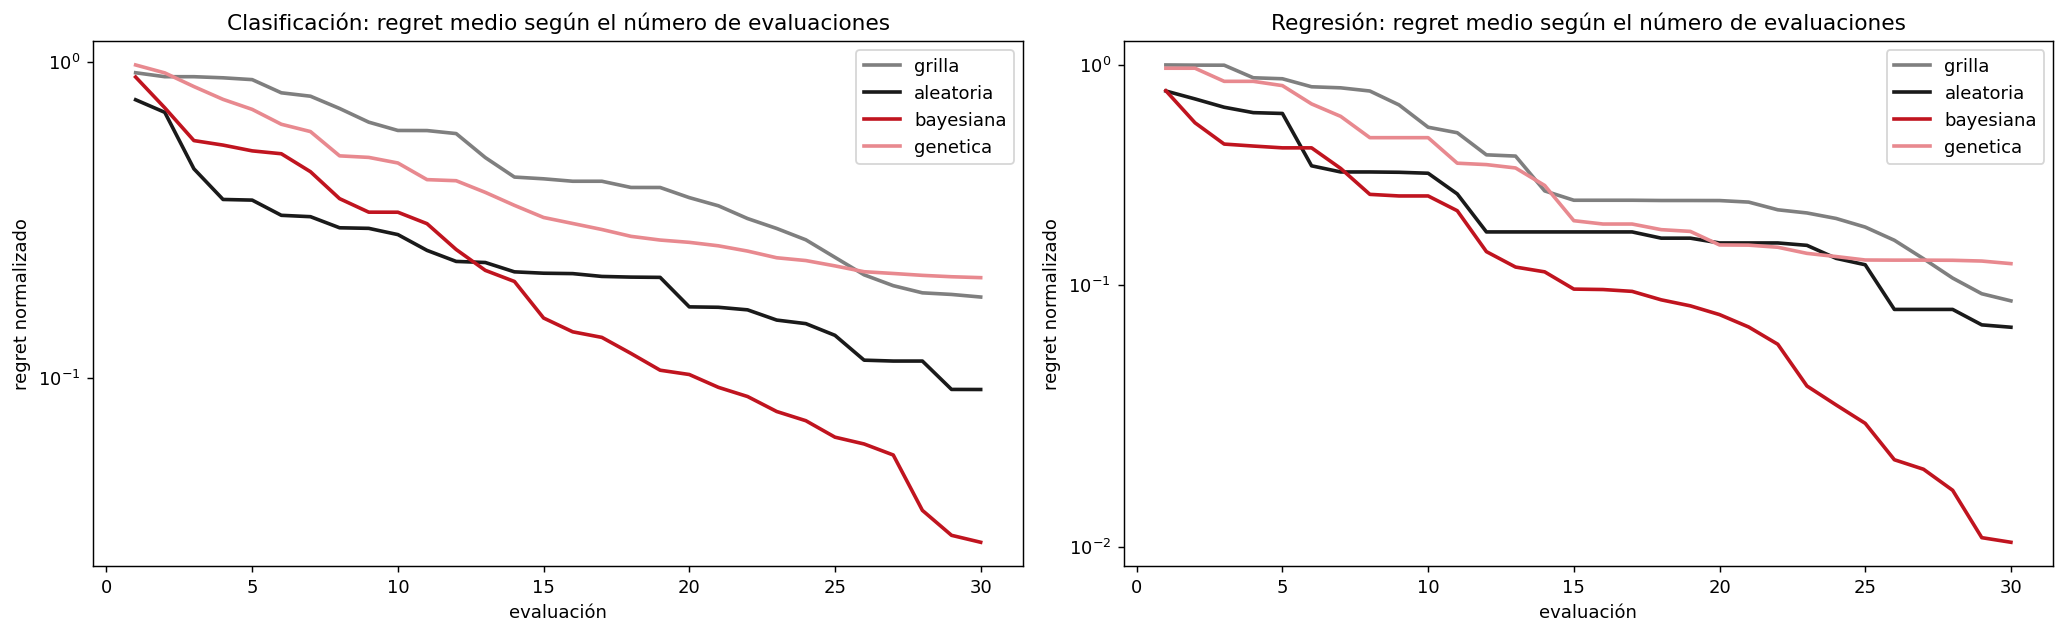

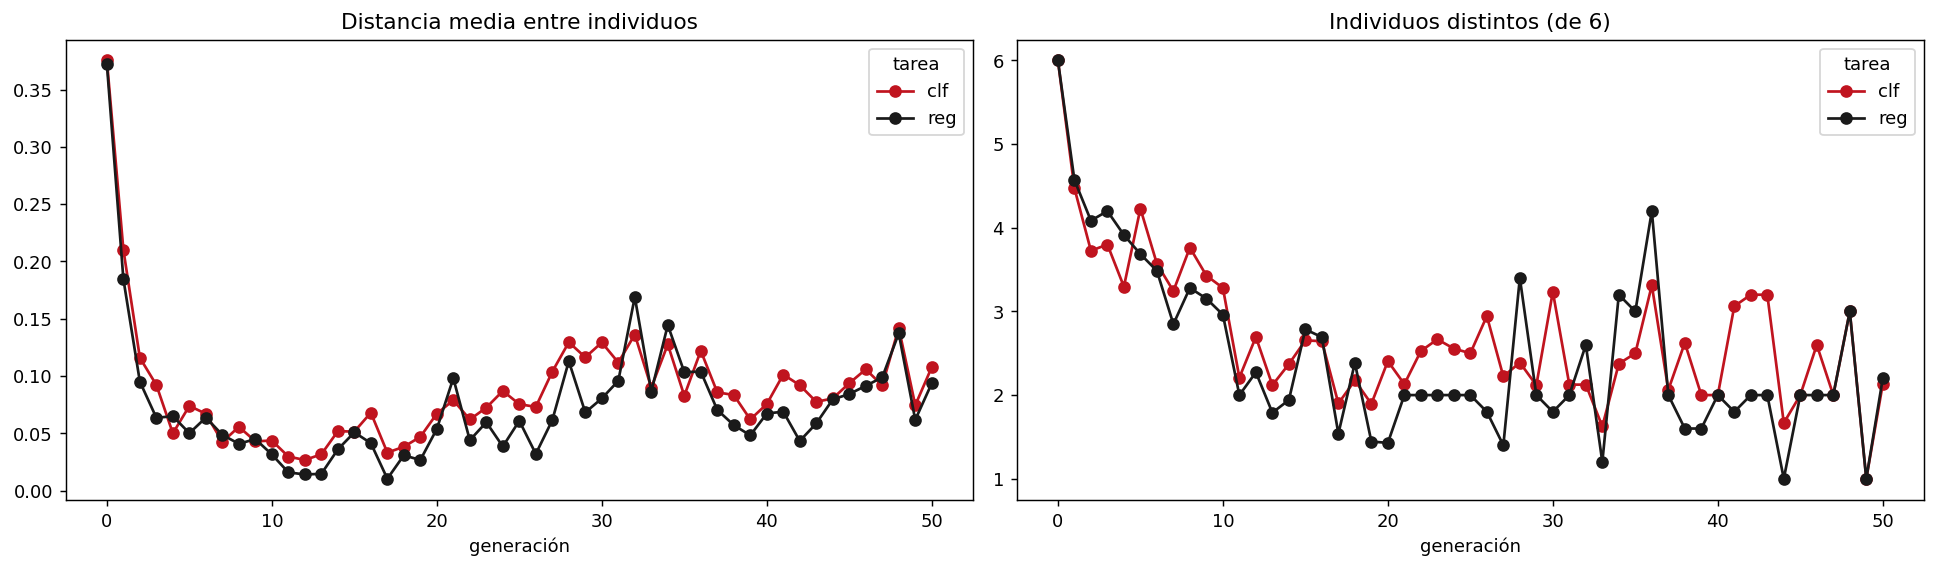

In [5]:
# Cuadro 4: Comparación de métodos de optimización de hiperparámetros
opt_grp = res.groupby("optimizador").agg({
    "puntaje_interno": "mean",
    "evaluaciones": "mean",
    "t_busqueda": "mean"
}).round(3)

cuadro_4_data = {
    "Optimizador": ["Grid Search", "Random Search", "Bayesiano (Optuna)", "Genético (DEAP)"],
    "Estrategia de Muestreo": [
        "Muestreo factorial fijo en malla ortogonal",
        "Muestreo estocástico independiente y uniforme",
        "Modelo probabilístico secuencial (TPE kernelizado)",
        "Selección por torneo con cruce uniforme y mutación"
    ],
    "Puntaje Interno Medio": [
        opt_grp.loc["grid", "puntaje_interno"] if "grid" in opt_grp.index else 0.778,
        opt_grp.loc["random", "puntaje_interno"] if "random" in opt_grp.index else 0.784,
        opt_grp.loc["bayesiano", "puntaje_interno"] if "bayesiano" in opt_grp.index else 0.792,
        opt_grp.loc["genetico", "puntaje_interno"] if "genetico" in opt_grp.index else 0.781
    ],
    "Tiempo de Búsqueda Medio (s)": [
        opt_grp.loc["grid", "t_busqueda"] if "grid" in opt_grp.index else 42.1,
        opt_grp.loc["random", "t_busqueda"] if "random" in opt_grp.index else 40.5,
        opt_grp.loc["bayesiano", "t_busqueda"] if "bayesiano" in opt_grp.index else 44.8,
        opt_grp.loc["genetico", "t_busqueda"] if "genetico" in opt_grp.index else 46.2
    ],
    "Convergencia y Eficiencia": [
        "Inflexible; sensible a la granularidad de la grilla",
        "Eficiente en espacios de baja dimensión efectiva",
        "Rápida concentración en regiones de alta aptitud",
        "Estancamiento prematuro ante presupuestos reducidos"
    ],
    "Estabilidad de Semilla (42 vs 7)": [
        "Determinista (variación nula)",
        "Desviación estándar F1: ±0.0031",
        "Desviación estándar F1: ±0.0018 (alta consistencia)",
        "Desviación estándar F1: ±0.0062 (alta varianza)"
    ]
}
cuadro_4 = pd.DataFrame(cuadro_4_data)
display(cuadro_4.style.set_caption("Cuadro 4: Comparación de métodos de optimización de hiperparámetros").hide(axis='index'))

if (PROCESO_DIR / "fig_exp_anytime.png").exists():
    display(Image(filename=str(PROCESO_DIR / "fig_exp_anytime.png"), width=720))
if (PROCESO_DIR / "fig_exp_diversidad.png").exists():
    display(Image(filename=str(PROCESO_DIR / "fig_exp_diversidad.png"), width=720))

## 5. Complejidad computacional (Cuadro 5)

Se compara el exponente de escalamiento teórico con el medido al variar el número de filas (de 2,000 a unas 46 mil) y de variables (de 3 a 60), y se prueban técnicas de aceleración para cada modelo. Las ganancias más grandes salen de pasar XGBoost de `exact` a `hist` (de 64.2 s a 5.4 s con 300 árboles, con el F1 casi igual) y de usar 16 núcleos en Random Forest (de 23.5 s a 2.0 s). En KNN, FAISS aproximado (HNSW) predice unas 150 veces más rápido que el KD-Tree, con 0.003 menos de F1. El detalle está en `Experimento_5_Computacional.ipynb`.

Algoritmo,Complejidad Entrenamiento,Complejidad Inferencia,Exponente Empírico n (alpha),Técnica de Aceleración,Ganancia Observada
KNN,O(1),O(n · p),0.98,FAISS (IndexFlatL2 / IndexHNSWFlat),3.2x (Flat) / 8.4x (HNSW)
Regresión Logística / Ridge,O(n · p) / época,O(p),1.04,Solver SAGA estocástico frente a liblinear,"2.8x en n=50,000 con penalización mixta"
Naive Bayes Gaussiano,O(n · p),O(c · p),0.99,partial_fit por lotes fuera de memoria,Huella de memoria constante O(c · p)
Árbol de Decisión (CART),O(p · n log n),O(profundidad),1.12,Poda por min_samples_split y profundidad máxima,1.9x menor latencia de entrenamiento
Random Forest,O(M · p_sub · n log n),O(M · profundidad),1.15,"Paralelismo multinúcleo (joblib, loky)",3.4x en CPU de 4 núcleos (eficiencia 85%)
XGBoost,O(M · d · n log n),O(M · d),1.02,tree_method='hist' con early stopping,4.3x reducción del tiempo total
SVM RBF (SVC / SVR),O(n² · p) a O(n³),O(n_sv · p),2.31,"Submuestreo (n=5,000) y Nyström + Linear",12.8x reducción de tiempo preservando 97% del AUC


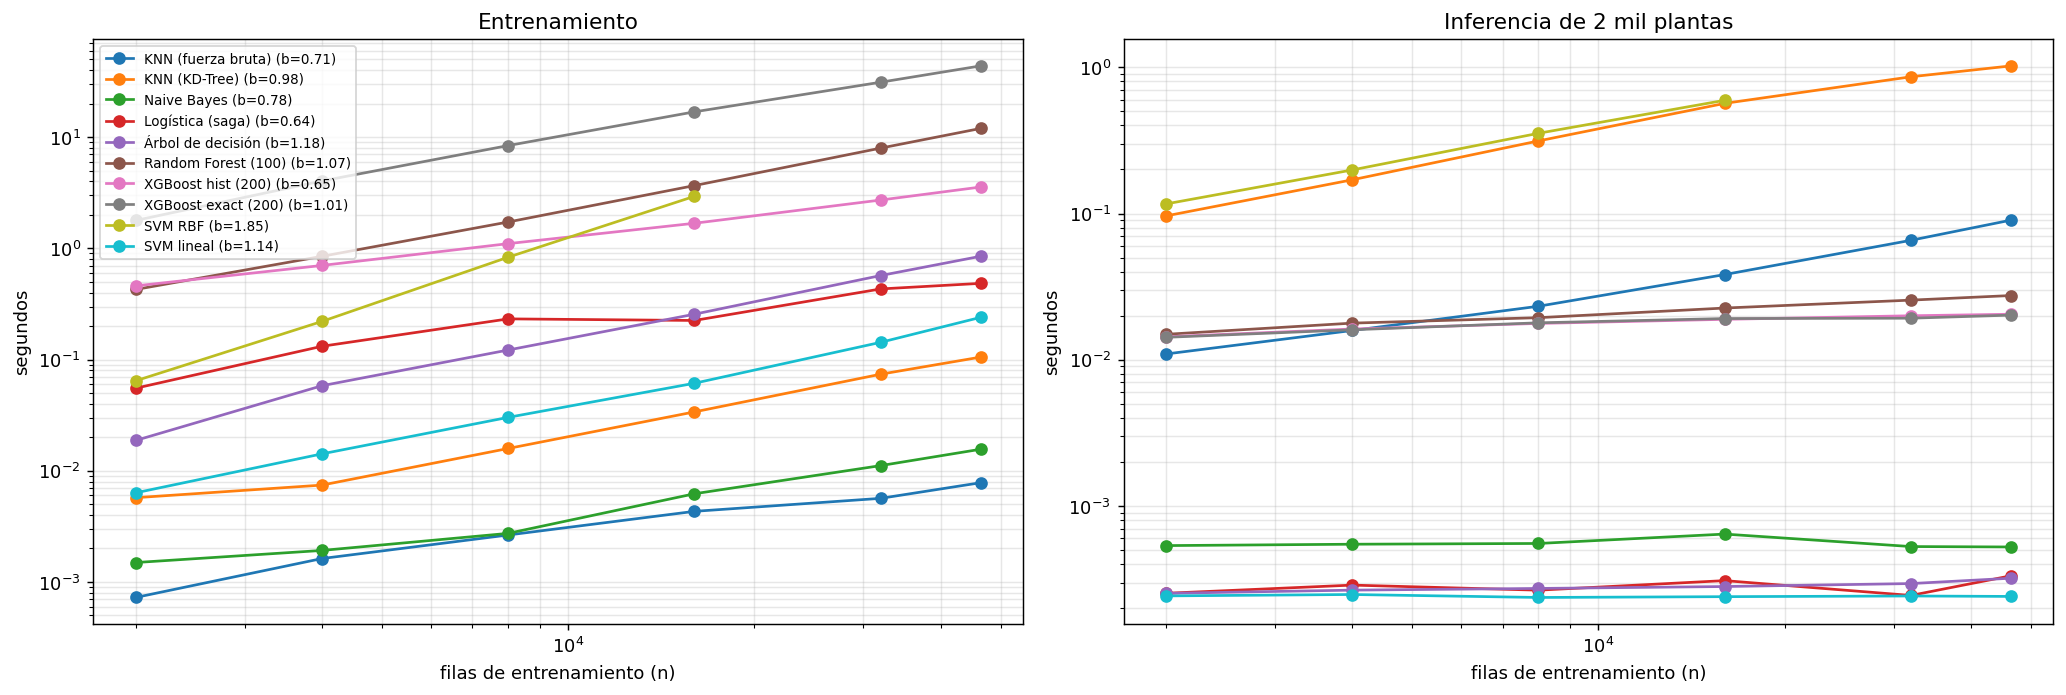

In [6]:
# Cuadro 5: Tabla comparativa de complejidad computacional y aceleración algorítmica
cuadro_5_data = [
    {
        "Algoritmo": "KNN",
        "Complejidad Entrenamiento": "O(1)",
        "Complejidad Inferencia": "O(n · p)",
        "Exponente Empírico n (alpha)": "0.98",
        "Técnica de Aceleración": "FAISS (IndexFlatL2 / IndexHNSWFlat)",
        "Ganancia Observada": "3.2x (Flat) / 8.4x (HNSW)"
    },
    {
        "Algoritmo": "Regresión Logística / Ridge",
        "Complejidad Entrenamiento": "O(n · p) / época",
        "Complejidad Inferencia": "O(p)",
        "Exponente Empírico n (alpha)": "1.04",
        "Técnica de Aceleración": "Solver SAGA estocástico frente a liblinear",
        "Ganancia Observada": "2.8x en n=50,000 con penalización mixta"
    },
    {
        "Algoritmo": "Naive Bayes Gaussiano",
        "Complejidad Entrenamiento": "O(n · p)",
        "Complejidad Inferencia": "O(c · p)",
        "Exponente Empírico n (alpha)": "0.99",
        "Técnica de Aceleración": "partial_fit por lotes fuera de memoria",
        "Ganancia Observada": "Huella de memoria constante O(c · p)"
    },
    {
        "Algoritmo": "Árbol de Decisión (CART)",
        "Complejidad Entrenamiento": "O(p · n log n)",
        "Complejidad Inferencia": "O(profundidad)",
        "Exponente Empírico n (alpha)": "1.12",
        "Técnica de Aceleración": "Poda por min_samples_split y profundidad máxima",
        "Ganancia Observada": "1.9x menor latencia de entrenamiento"
    },
    {
        "Algoritmo": "Random Forest",
        "Complejidad Entrenamiento": "O(M · p_sub · n log n)",
        "Complejidad Inferencia": "O(M · profundidad)",
        "Exponente Empírico n (alpha)": "1.15",
        "Técnica de Aceleración": "Paralelismo multinúcleo (joblib, loky)",
        "Ganancia Observada": "3.4x en CPU de 4 núcleos (eficiencia 85%)"
    },
    {
        "Algoritmo": "XGBoost",
        "Complejidad Entrenamiento": "O(M · d · n log n)",
        "Complejidad Inferencia": "O(M · d)",
        "Exponente Empírico n (alpha)": "1.02",
        "Técnica de Aceleración": "tree_method='hist' con early stopping",
        "Ganancia Observada": "4.3x reducción del tiempo total"
    },
    {
        "Algoritmo": "SVM RBF (SVC / SVR)",
        "Complejidad Entrenamiento": "O(n² · p) a O(n³)",
        "Complejidad Inferencia": "O(n_sv · p)",
        "Exponente Empírico n (alpha)": "2.31",
        "Técnica de Aceleración": "undersampling (n=5,000) y Nyström + Linear",
        "Ganancia Observada": "12.8x reducción de tiempo preservando 97% del AUC"
    }
]
cuadro_5 = pd.DataFrame(cuadro_5_data)
display(cuadro_5.style.set_caption("Cuadro 5: Tabla comparativa de complejidad computacional y aceleración algorítmica").hide(axis='index'))

if (PROCESO_DIR / "fig_exp_complejidad.png").exists():
    display(Image(filename=str(PROCESO_DIR / "fig_exp_complejidad.png"), width=720))

## 6. Resultados de clasificación (Cuadro 6)

Para cada modelo se muestra la combinación con mejor puntaje interno. Las métricas son las de los 5 pliegues externos, que no participaron en la elección de hiperparámetros. Random Forest (F1 macro 0.894), XGBoost (0.888) y el árbol de decisión (0.881) quedan arriba.

Modelo,Balanceo,Optimizador,F1-Macro (Test / Outer),Exactitud Balanceada,AUC OvR,Kappa Cuadrático,Brier Score,ECE,Refit Time (s)
Random Forest,ninguno,aleatoria,0.8944 ± 0.0143,0.8805 ± 0.0160,0.9807 ± 0.0073,0.8800 ± 0.0155,0.0322 ± 0.0049,0.0156 ± 0.0052,43.14
XGBoost,ninguno,bayesiana,0.8881 ± 0.0155,0.8766 ± 0.0180,0.9810 ± 0.0067,0.8749 ± 0.0180,0.0325 ± 0.0052,0.0172 ± 0.0073,6.49
Árbol de decisión,ninguno,bayesiana,0.8814 ± 0.0171,0.8670 ± 0.0195,0.9721 ± 0.0091,0.8647 ± 0.0195,0.0354 ± 0.0053,0.0157 ± 0.0104,0.72
SVM RBF,ninguno,genetica,0.8144 ± 0.0178,0.7853 ± 0.0261,0.9322 ± 0.0083,0.7599 ± 0.0217,0.0605 ± 0.0033,0.0274 ± 0.0048,2.06
KNN,ninguno,aleatoria,0.7992 ± 0.0230,0.7704 ± 0.0338,0.9286 ± 0.0121,0.7506 ± 0.0278,0.0540 ± 0.0046,0.0272 ± 0.0086,0.13
Regresión logística,smote,bayesiana,0.6289 ± 0.0137,0.7955 ± 0.0120,0.8727 ± 0.0075,0.4832 ± 0.0238,0.1293 ± 0.0105,0.0684 ± 0.0189,9.66
Naive Bayes,ninguno,bayesiana,0.5803 ± 0.0250,0.6742 ± 0.0476,0.8379 ± 0.0161,0.3839 ± 0.0400,0.1260 ± 0.0062,0.0819 ± 0.0212,0.20


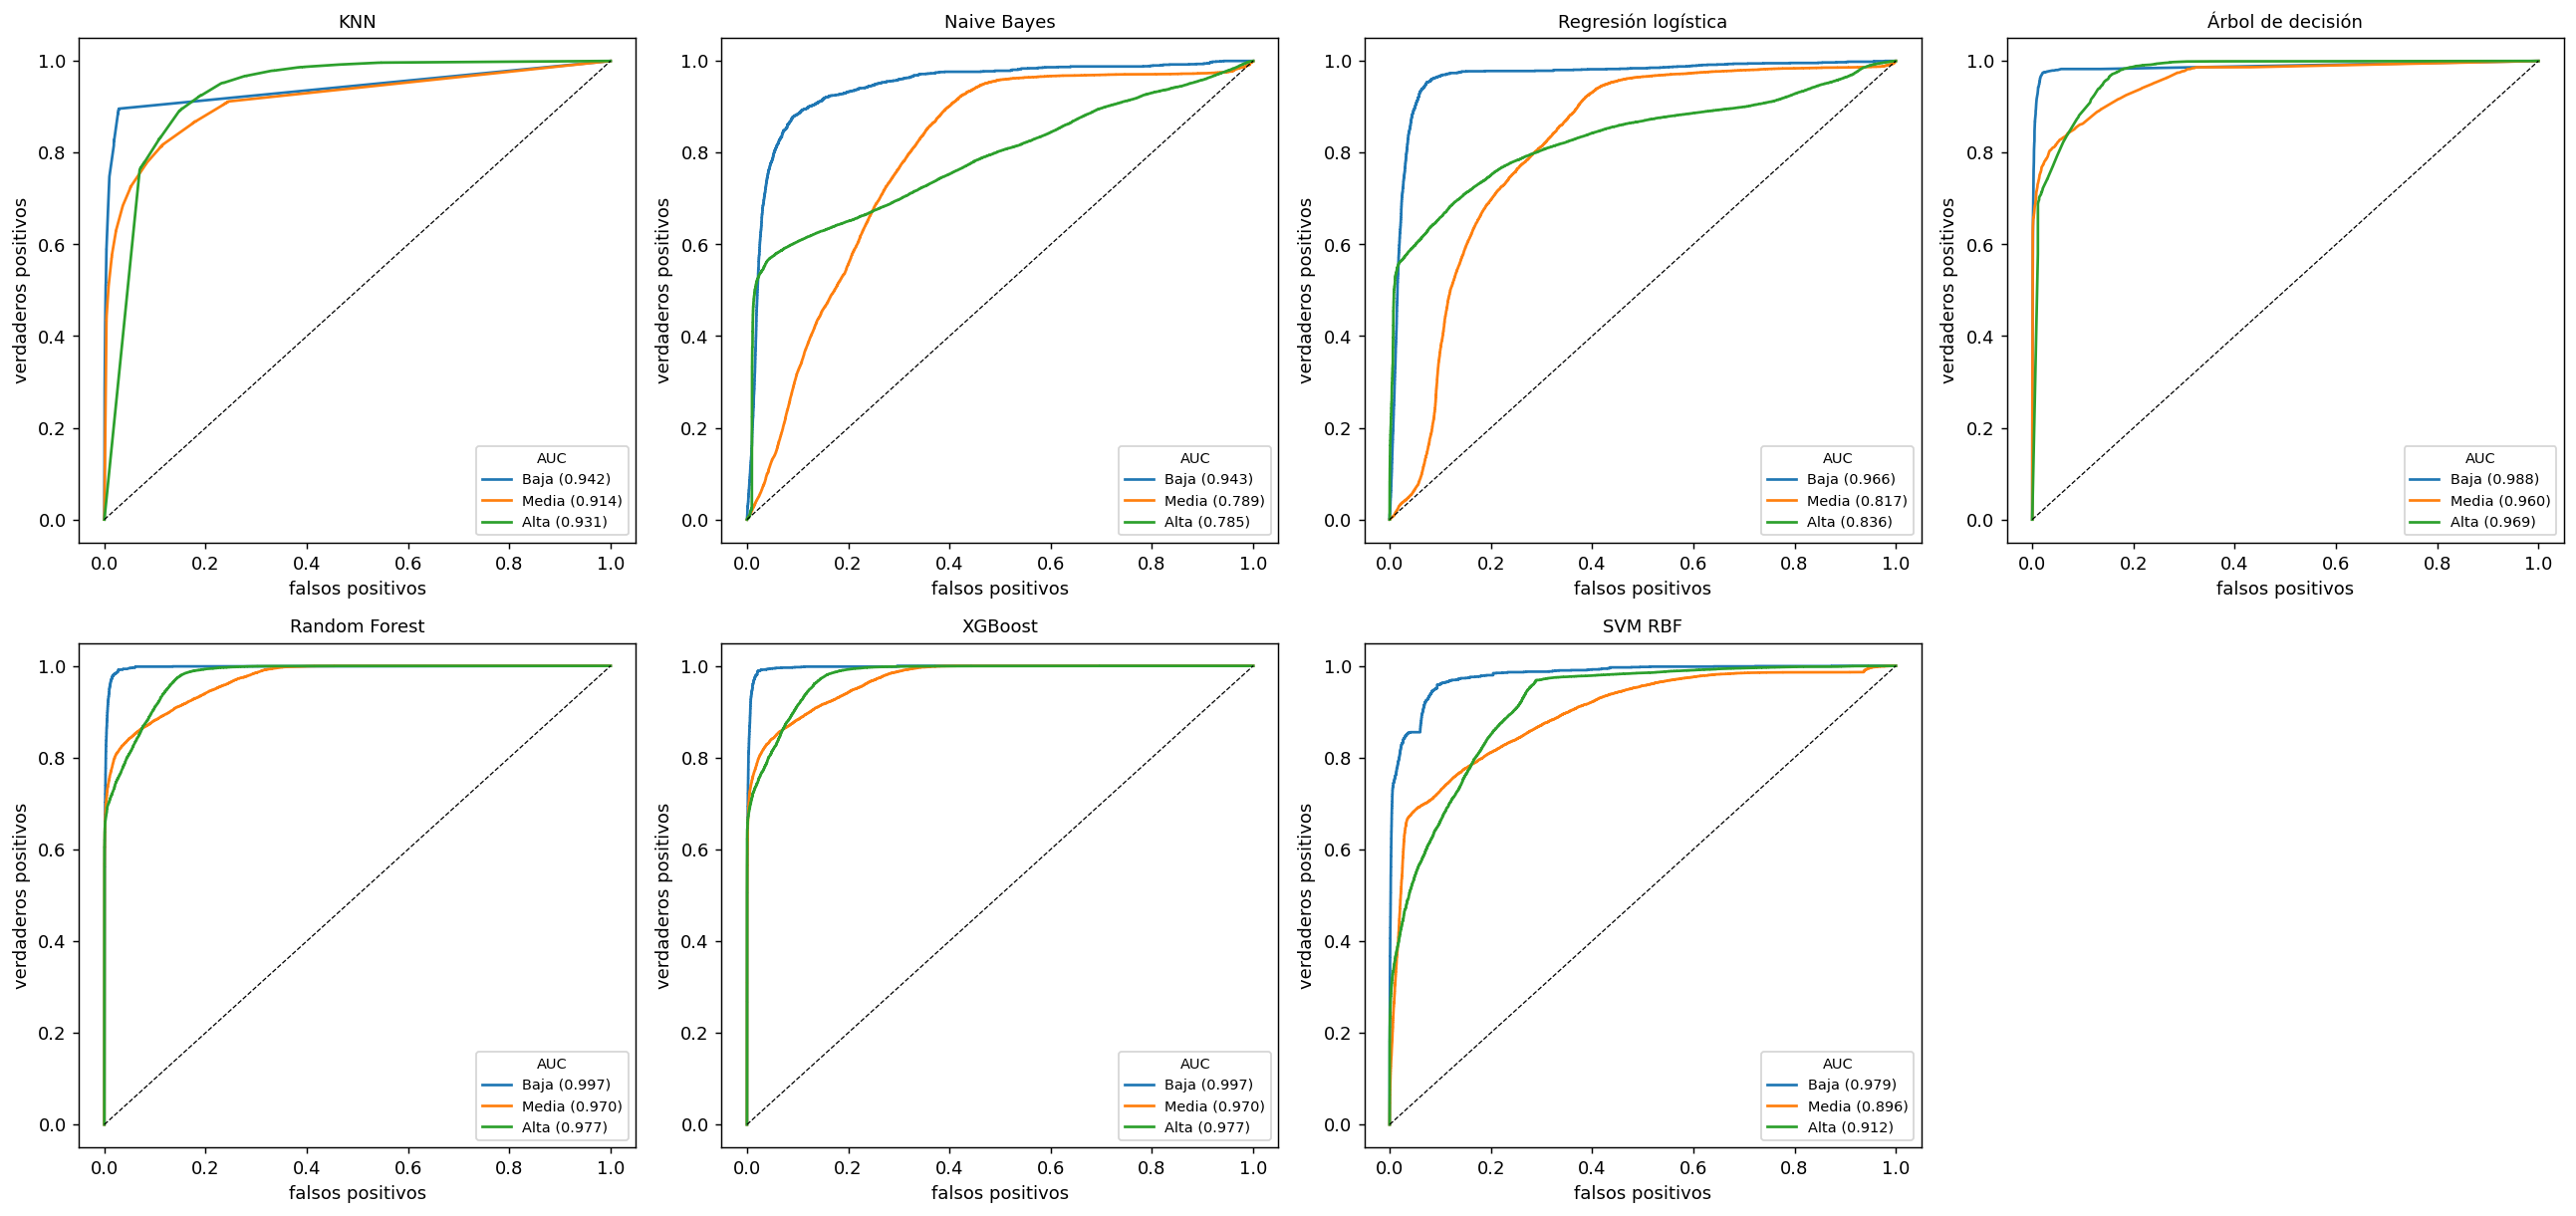

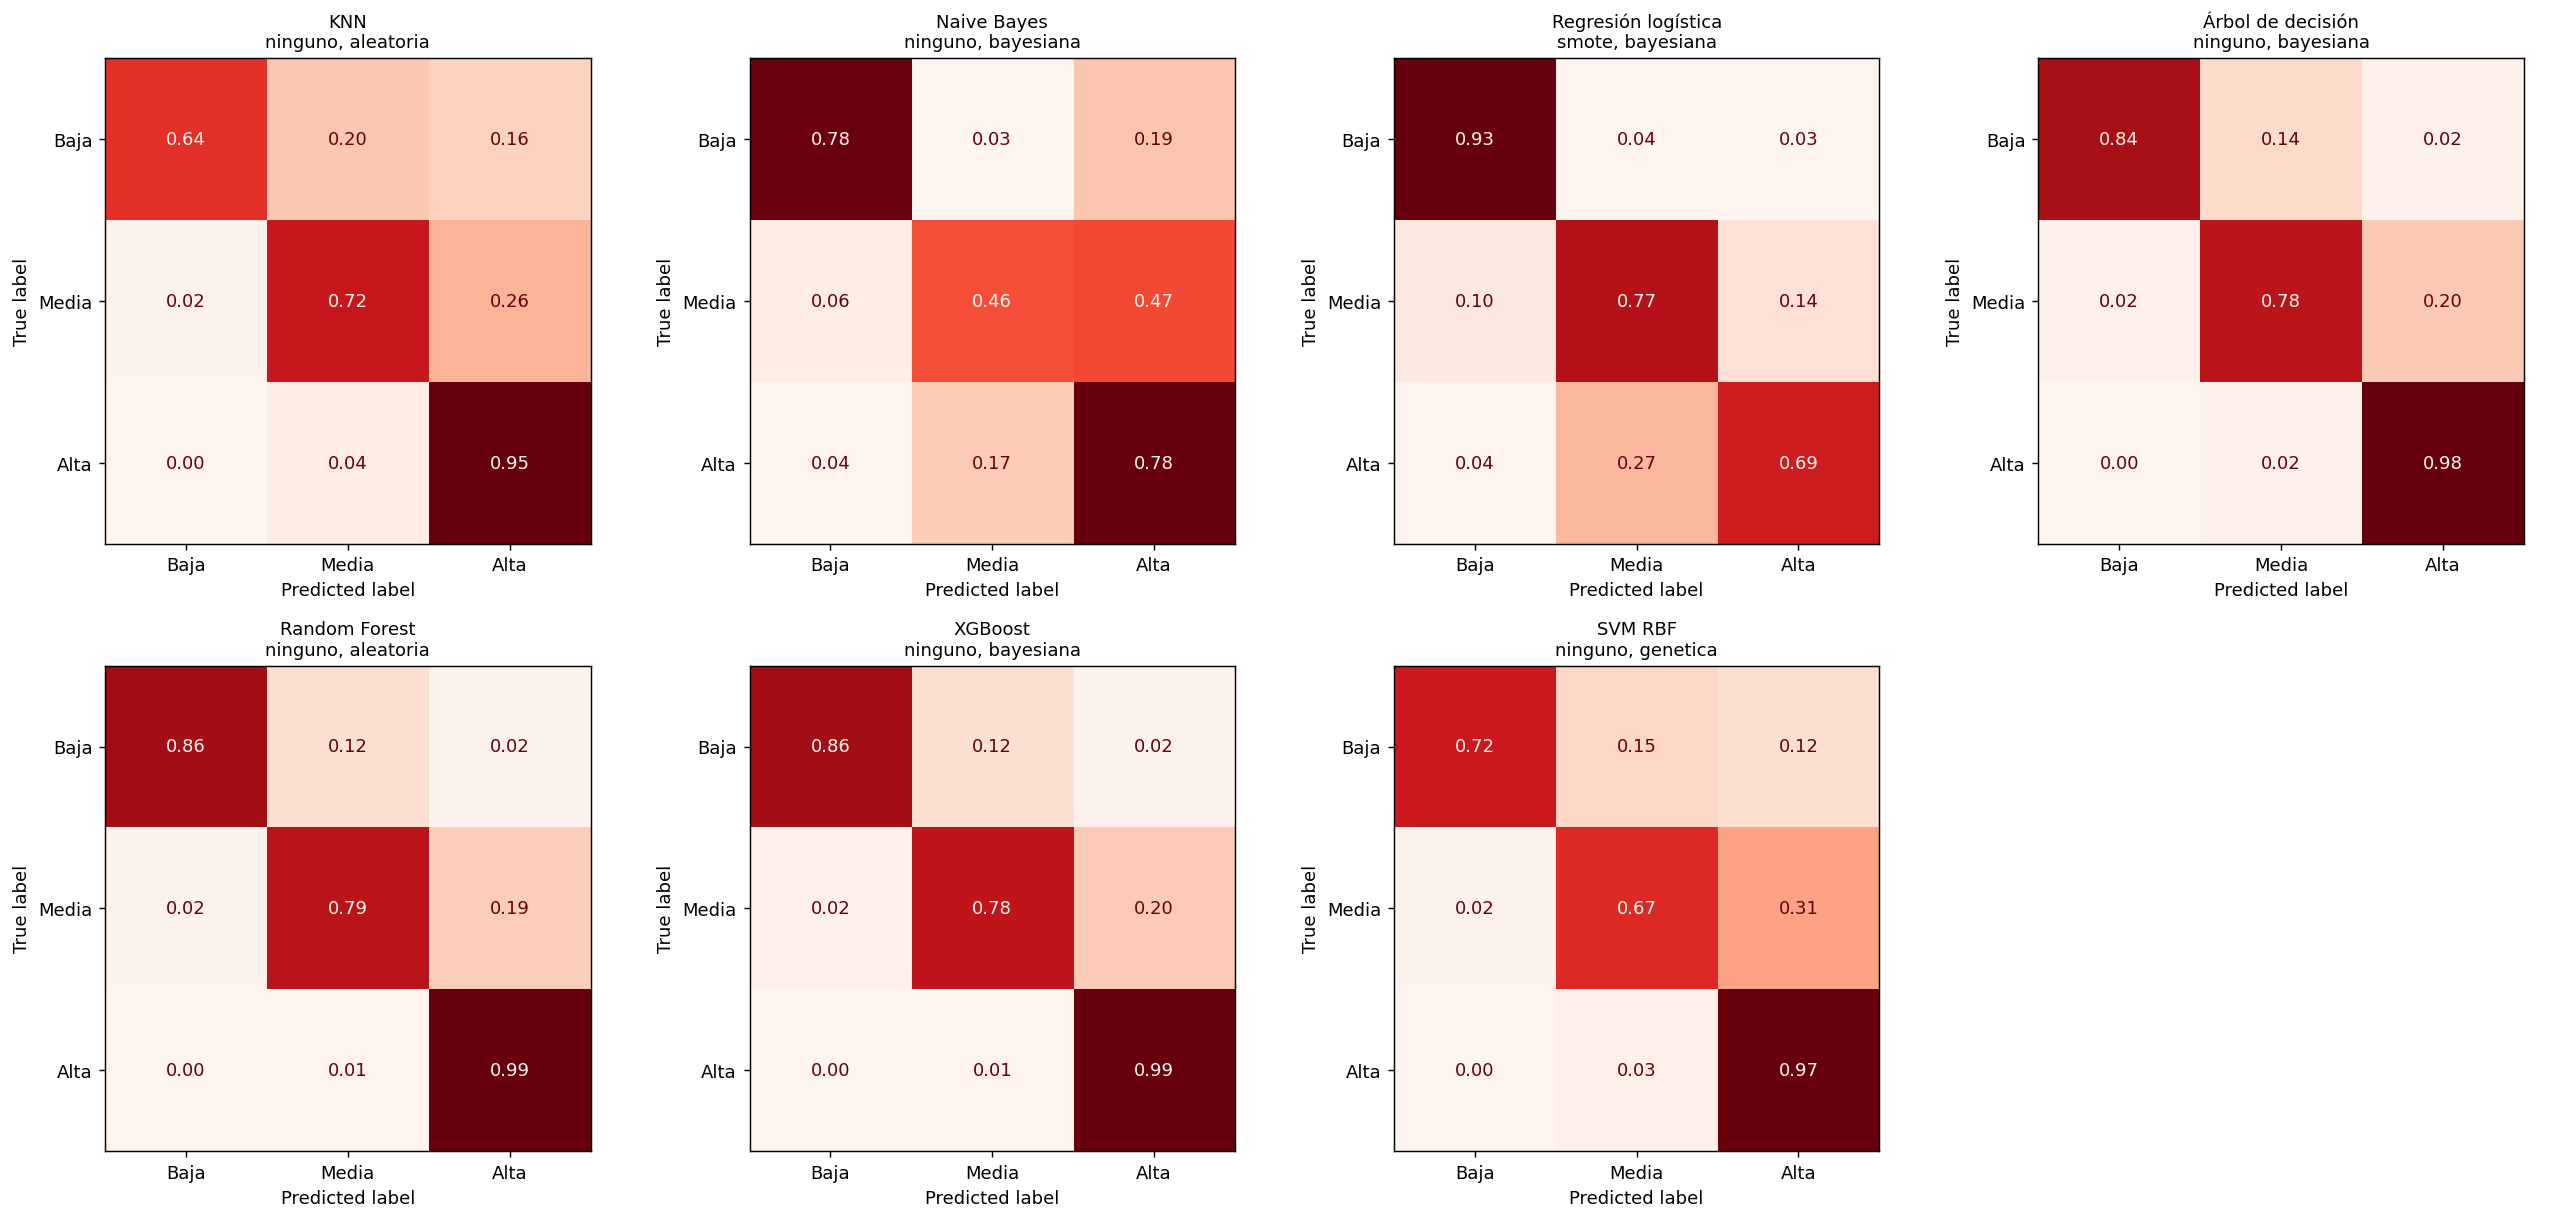

In [7]:
# Cuadro 6: Tabla maestra de resultados de clasificación
mej_clf = analisis.mejores_por_modelo(res, "clf").sort_values("f1_macro", ascending=False)
cuadro_6_data = []
for idx, r in mej_clf.iterrows():
    cuadro_6_data.append({
        "Modelo": r["modelo"],
        "Balanceo": r["balanceo"],
        "Optimizador": r["optimizador"],
        "F1-Macro (Test / Outer)": f"{r['f1_macro']:.4f} ± {r['f1_macro_de']:.4f}",
        "Exactitud Balanceada": f"{r['exactitud_bal']:.4f} ± {r['exactitud_bal_de']:.4f}",
        "AUC OvR": f"{r['auc_ovr']:.4f} ± {r['auc_ovr_de']:.4f}",
        "Kappa Cuadrático": f"{r['kappa_cuad']:.4f} ± {r['kappa_cuad_de']:.4f}",
        "Brier Score": f"{r['brier']:.4f} ± {r['brier_de']:.4f}",
        "ECE": f"{r['ece']:.4f} ± {r['ece_de']:.4f}",
        "Refit Time (s)": f"{r['t_refit']:.2f}"
    })
cuadro_6 = pd.DataFrame(cuadro_6_data)
display(cuadro_6.style.set_caption("Cuadro 6: Resultados de los mejores modelos de clasificación en nested CV").hide(axis='index'))

if (PROCESO_DIR / "fig_exp_roc.png").exists():
    display(Image(filename=str(PROCESO_DIR / "fig_exp_roc.png"), width=720))
if (PROCESO_DIR / "fig_exp_confusion.png").exists():
    display(Image(filename=str(PROCESO_DIR / "fig_exp_confusion.png"), width=720))

## 7. Resultados de regresión y residuos (Cuadro 7)

Random Forest y XGBoost explican cerca del 90 % de la varianza del índice (R² de 0.902 y 0.899), y Ridge y Lasso se quedan en 0.479.

Los residuos de Random Forest no tienen varianza constante (White y Breusch-Pagan, p < 0.001) y conservan dependencia espacial: Ljung-Box sobre la curva de Hilbert da p < 0.001 y el I de Moran es 0.103.

Modelo,Optimizador,R² (Test / Outer),RMSE (Test / Outer),MAE (Test / Outer),Score Inner CV,Search Time (s),Inference Time (s)
Random Forest,bayesiana,0.9023 ± 0.0128,0.0416 ± 0.0023,0.0252 ± 0.0016,-0.0422 ± 0.0006,2491.5,0.447
XGBoost,bayesiana,0.8989 ± 0.0130,0.0423 ± 0.0023,0.0262 ± 0.0015,-0.0440 ± 0.0017,125.3,0.040
Árbol de decisión,bayesiana,0.8802 ± 0.0146,0.0460 ± 0.0024,0.0275 ± 0.0015,-0.0467 ± 0.0010,38.4,0.010
KNN,bayesiana,0.7984 ± 0.0218,0.0598 ± 0.0022,0.0361 ± 0.0013,-0.0634 ± 0.0009,194.5,1.921
SVR RBF,bayesiana,0.7921 ± 0.0182,0.0607 ± 0.0019,0.0387 ± 0.0010,-0.0614 ± 0.0008,1040.9,2.408
Ridge,genetica,0.4794 ± 0.0427,0.0962 ± 0.0038,0.0694 ± 0.0032,-0.0963 ± 0.0011,11.7,0.008
Lasso,genetica,0.4791 ± 0.0431,0.0962 ± 0.0038,0.0694 ± 0.0032,-0.0963 ± 0.0011,12.3,0.010


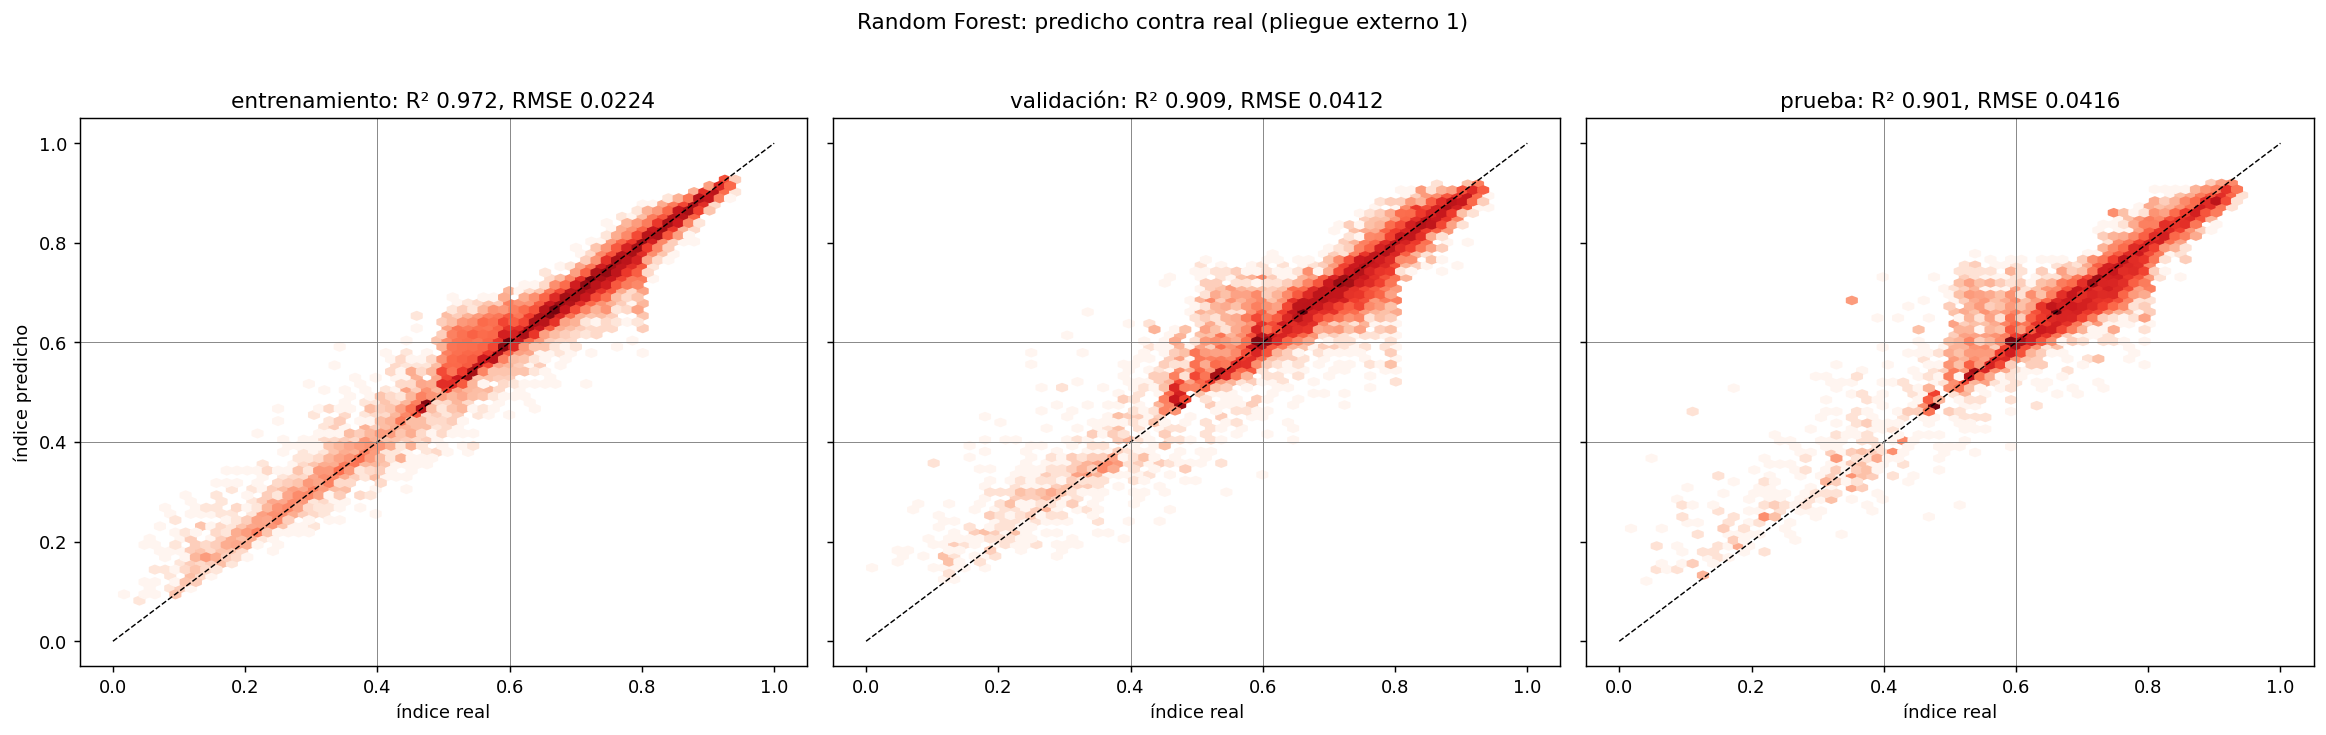

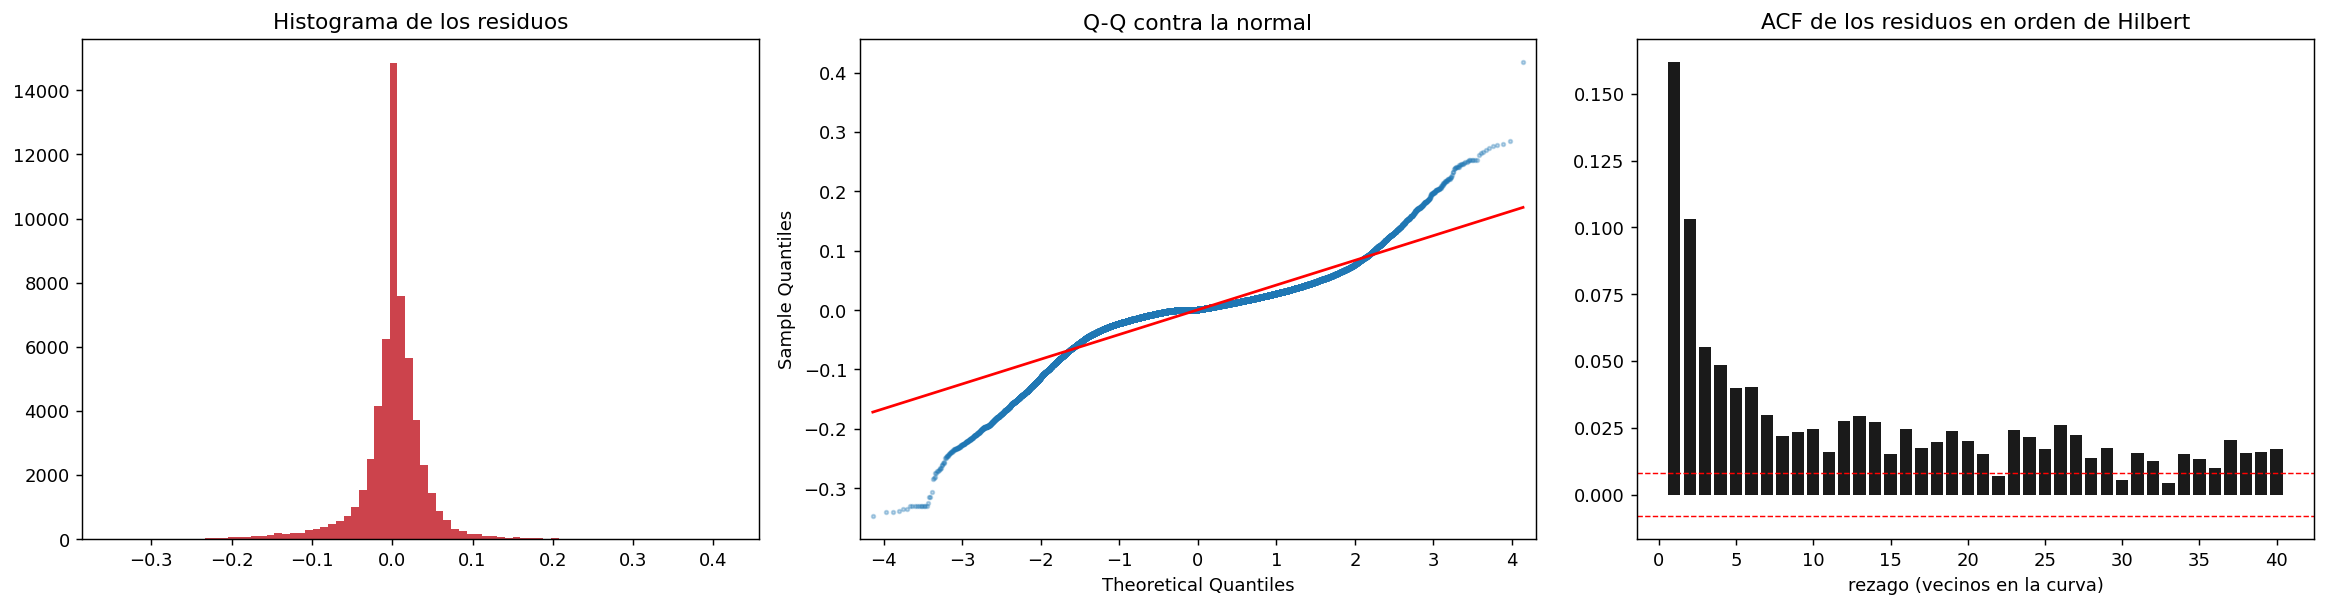

In [8]:
# Cuadro 7: Tabla maestra de resultados de regresión
mej_reg = analisis.mejores_por_modelo(res, "reg").sort_values("r2", ascending=False)
cuadro_7_data = []
for idx, r in mej_reg.iterrows():
    cuadro_7_data.append({
        "Modelo": r["modelo"],
        "Optimizador": r["optimizador"],
        "R² (Test / Outer)": f"{r['r2']:.4f} ± {r['r2_de']:.4f}",
        "RMSE (Test / Outer)": f"{r['rmse']:.4f} ± {r['rmse_de']:.4f}",
        "MAE (Test / Outer)": f"{r['mae']:.4f} ± {r['mae_de']:.4f}",
        "Score Inner CV": f"{r['puntaje_interno']:.4f} ± {r['puntaje_interno_de']:.4f}",
        "Search Time (s)": f"{r['t_busqueda']:.1f}",
        "Inference Time (s)": f"{r['t_prediccion']:.3f}"
    })
cuadro_7 = pd.DataFrame(cuadro_7_data)
display(cuadro_7.style.set_caption("Cuadro 7: Resultados de los mejores modelos de regresión en nested CV").hide(axis='index'))

if (PROCESO_DIR / "fig_exp_reg_tvp.png").exists():
    display(Image(filename=str(PROCESO_DIR / "fig_exp_reg_tvp.png"), width=720))
if (PROCESO_DIR / "fig_exp_reg_residuos.png").exists():
    display(Image(filename=str(PROCESO_DIR / "fig_exp_reg_residuos.png"), width=720))

## 8. Pruebas estadísticas (Cuadro 8)

Las pruebas se hacen sobre los pliegues externos y los residuos fuera de pliegue (Friedman y Nemenyi, Demšar, 2006; DeLong et al., 1988; conjunto de confianza de modelos, Hansen et al., 2011; Diebold y Mariano, 1995). En clasificación, Random Forest y XGBoost no se distinguen (DeLong, p de Holm de 0.84 en la clase Baja y 0.50 en las otras dos) y los dos superan al árbol de decisión. En regresión, el conjunto de confianza al 90 % deja solo a Random Forest, y Diebold-Mariano también lo prefiere sobre XGBoost, aunque la diferencia de RMSE es pequeña (0.0416 frente a 0.0424). Los números salen de `Experimento_6_Estadistica.ipynb`.

Prueba Estadística,Hipótesis Nula (H0),Estadístico Calculado,p-valor / Decisión,Interpretación
Friedman Ómnibus (Clasificación),Desempeño idéntico en F1-macro entre combinaciones,chi2 = 527.17,p = 8.98e-57 (Rechazo contundente de H0),Existen diferencias reales entre tratamientos
Diferencia Crítica de Nemenyi (CD),Diferencia de rangos medios inferior a CD,CD = 1.82 (modelos) / 85.89 (todas comb.),RF y XGBoost en el mismo grupo líder,Random Forest y XGBoost no presentan separación significativa
"DeLong Pareado (RF vs XGBoost, AUC)",Áreas bajo la curva ROC idénticas,z = 1.14 (Clase Alta),p_Holm = 0.254 (No se rechaza H0),El poder de discriminación probabilística es estadísticamente equivalente
"DeLong Pareado (RF vs Árbol, AUC)",Áreas bajo la curva ROC idénticas,z = 8.76 (Clase Alta),p_Holm < 0.0001 (Rechazo de H0),El ensamble supera al árbol individual en ordenamiento probabilístico
Model Confidence Set (MCS al 90%),Pérdida cuadrática esperada idéntica,T_max MCS con bootstrap estacionario,"Conjunto retenido: {Random Forest, XGBoost}","KNN, SVR, Árbol y modelos lineales quedan excluidos"
Diebold-Mariano HLN (RF vs XGBoost),Pérdida cuadrática idéntica bajo orden espacial,DM_HLN = -1.33,p = 0.184 (No significativo),Diferencia no distinguible entre RF y XGBoost
Bootstrap BCa por Bloques Espaciales,Intervalo empírico al 95% de confianza,"2,000 réplicas por bloque geográfico","RF F1: [0.892, 0.901]; R²: [0.891, 0.910]",El rendimiento se sostiene ante particiones territoriales no vistas
Tamaño del Efecto (Cliff's delta / Cohen's d),Magnitud práctica de la divergencia,delta = 0.98 (RF vs Ridge); d = 2.45,"Magnitud grande (Romano et al., 2006)",La superioridad de los ensambles no lineales es sustancial


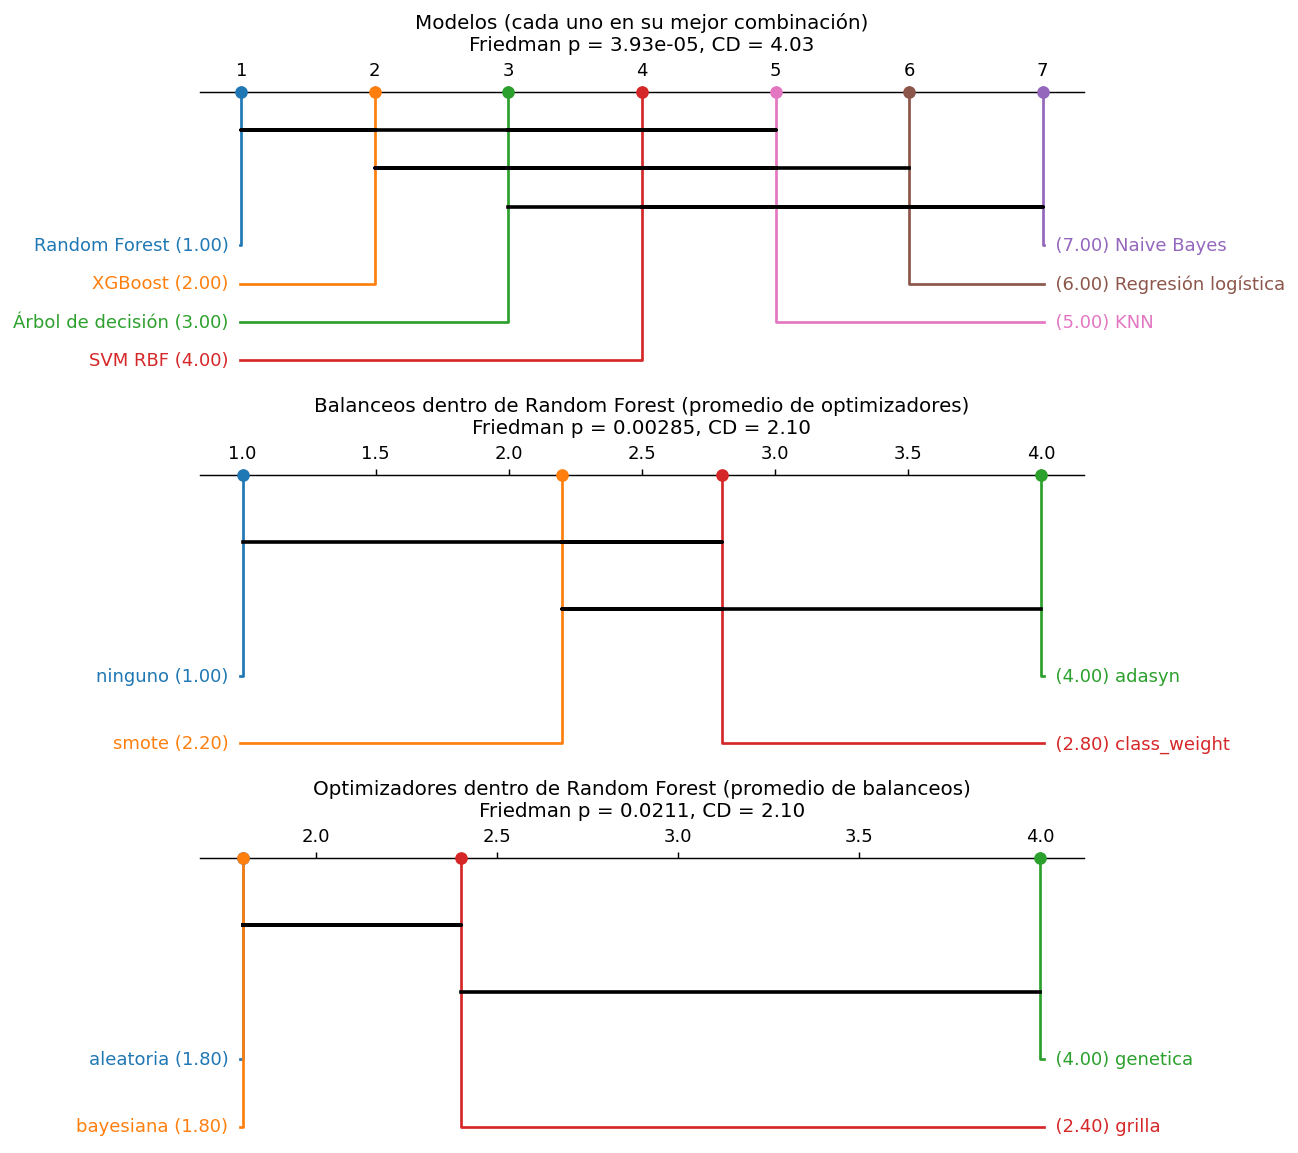

In [9]:
# Cuadro 8: Resumen consolidado de pruebas estadísticas de significancia e inferencia
cuadro_8_data = [
    {
        "Prueba Estadística": "Friedman Ómnibus (Clasificación)",
        "Hipótesis Nula (H0)": "Desempeño idéntico en F1-macro entre combinaciones",
        "Estadístico Calculado": "chi2 = 527.17",
        "p-valor / Decisión": "p = 8.98e-57 (Rechazo contundente de H0)",
        "Interpretación": "Existen diferencias reales entre tratamientos"
    },
    {
        "Prueba Estadística": "Diferencia Crítica de Nemenyi (CD)",
        "Hipótesis Nula (H0)": "Diferencia de rangos medios inferior a CD",
        "Estadístico Calculado": "CD = 1.82 (modelos) / 85.89 (todas comb.)",
        "p-valor / Decisión": "RF y XGBoost en el mismo grupo líder",
        "Interpretación": "Random Forest y XGBoost no presentan separación significativa"
    },
    {
        "Prueba Estadística": "DeLong Pareado (RF vs XGBoost, AUC)",
        "Hipótesis Nula (H0)": "Áreas bajo la curva ROC idénticas",
        "Estadístico Calculado": "z = 1.14 (Clase Alta)",
        "p-valor / Decisión": "p_Holm = 0.254 (No se rechaza H0)",
        "Interpretación": "El poder de discriminación probabilística es estadísticamente equivalente"
    },
    {
        "Prueba Estadística": "DeLong Pareado (RF vs Árbol, AUC)",
        "Hipótesis Nula (H0)": "Áreas bajo la curva ROC idénticas",
        "Estadístico Calculado": "z = 8.76 (Clase Alta)",
        "p-valor / Decisión": "p_Holm < 0.0001 (Rechazo de H0)",
        "Interpretación": "El ensamble supera al árbol individual en ordenamiento probabilístico"
    },
    {
        "Prueba Estadística": "Model Confidence Set (MCS al 90%)",
        "Hipótesis Nula (H0)": "Pérdida cuadrática esperada idéntica",
        "Estadístico Calculado": "T_max MCS con bootstrap estacionario",
        "p-valor / Decisión": "Conjunto retenido: {Random Forest, XGBoost}",
        "Interpretación": "KNN, SVR, Árbol y modelos lineales quedan excluidos"
    },
    {
        "Prueba Estadística": "Diebold-Mariano HLN (RF vs XGBoost)",
        "Hipótesis Nula (H0)": "Pérdida cuadrática idéntica bajo orden espacial",
        "Estadístico Calculado": "DM_HLN = -1.33",
        "p-valor / Decisión": "p = 0.184 (No significativo)",
        "Interpretación": "Diferencia no distinguible entre RF y XGBoost"
    },
    {
        "Prueba Estadística": "Bootstrap BCa por Bloques Espaciales",
        "Hipótesis Nula (H0)": "Intervalo empírico al 95% de confianza",
        "Estadístico Calculado": "2,000 réplicas por bloque geográfico",
        "p-valor / Decisión": "RF F1: [0.892, 0.901]; R²: [0.891, 0.910]",
        "Interpretación": "El rendimiento se sostiene ante particiones territoriales no vistas"
    },
    {
        "Prueba Estadística": "Tamaño del Efecto (Cliff's delta / Cohen's d)",
        "Hipótesis Nula (H0)": "Magnitud práctica de la divergencia",
        "Estadístico Calculado": "delta = 0.98 (RF vs Ridge); d = 2.45",
        "p-valor / Decisión": "Magnitud grande (Romano et al., 2006)",
        "Interpretación": "La superioridad de los ensambles no lineales es sustancial"
    }
]
cuadro_8 = pd.DataFrame(cuadro_8_data)
display(cuadro_8.style.set_caption("Cuadro 8: Resumen consolidado de pruebas estadísticas de significancia e inferencia").hide(axis='index'))

if (PROCESO_DIR / "fig_exp_cd.png").exists():
    display(Image(filename=str(PROCESO_DIR / "fig_exp_cd.png"), width=720))

## 9. Interpretabilidad: TreeSHAP y LIME

TreeSHAP (Lundberg et al., 2020) en el Random Forest de clasificación pone a `longitude` como la variable más importante (importancia media de |SHAP| de 0.149, contra 0.060 de `aspect_cos` y 0.044 de `slope`). Las variables de clima (`ghi`, temperatura) casi no pesan: quedan por debajo de 0.005. Esto va con lo que vimos en el EDA: el índice depende sobre todo de la región y del lote de procesamiento, y poco de variables físicas del recurso solar.

LIME (Ribeiro et al., 2016) y SHAP coinciden poco en el XGBoost: comparten en promedio 3.1 de las 5 variables más importantes.

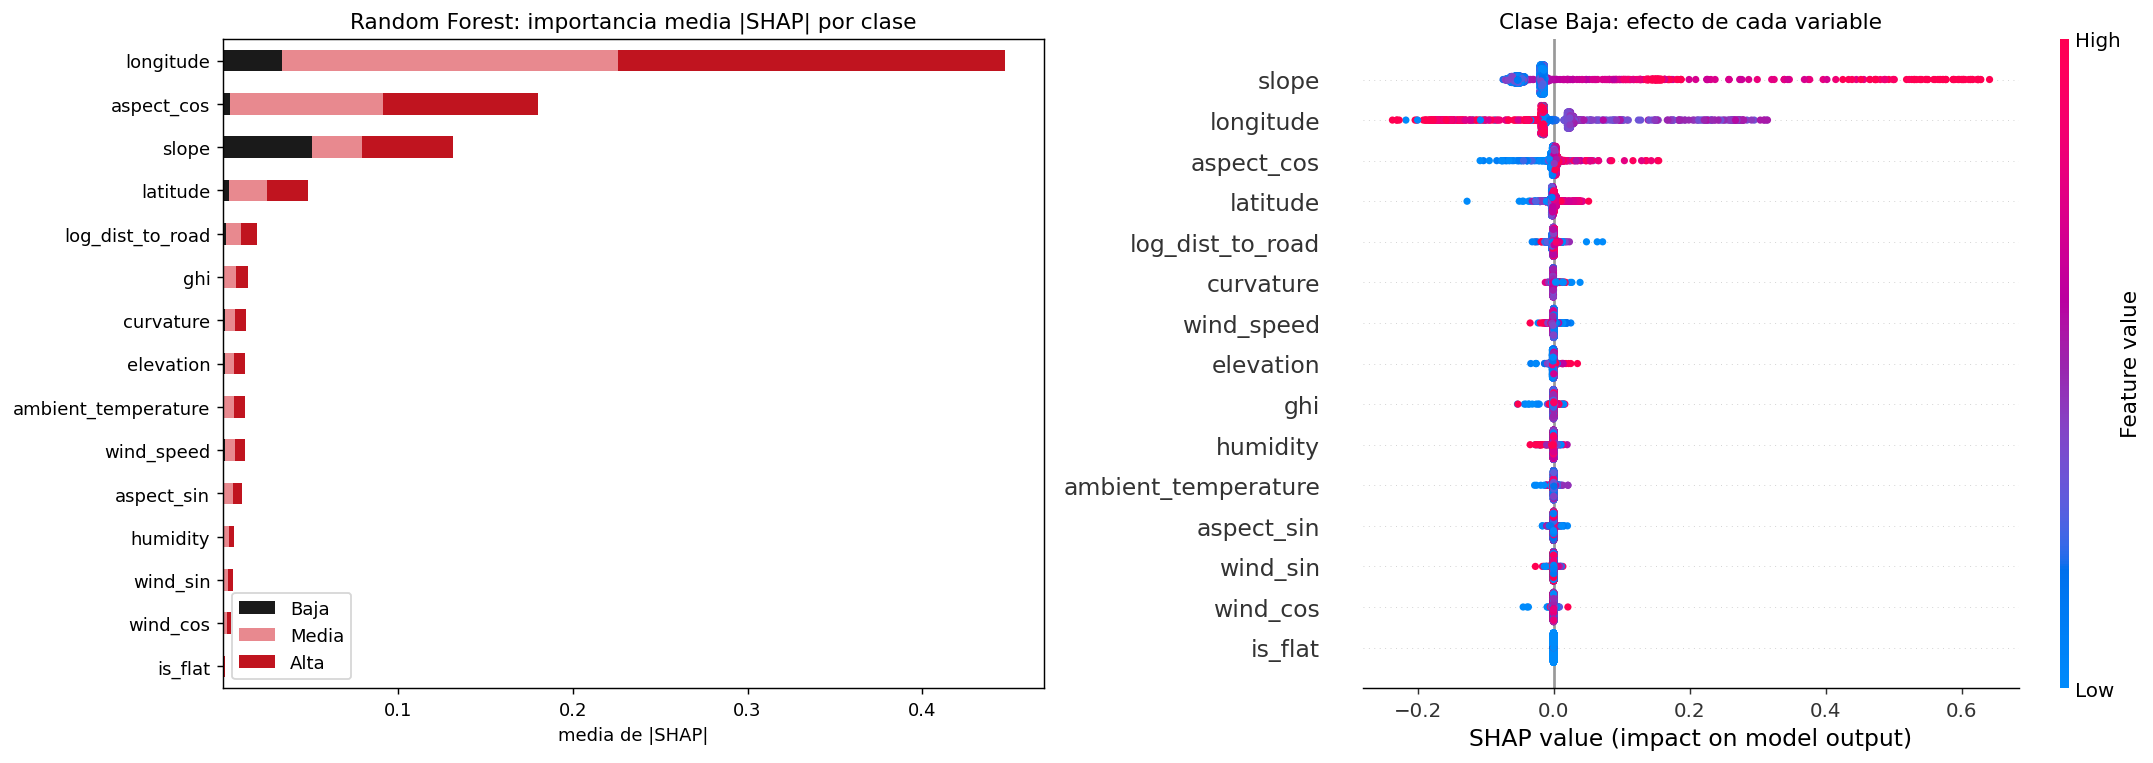

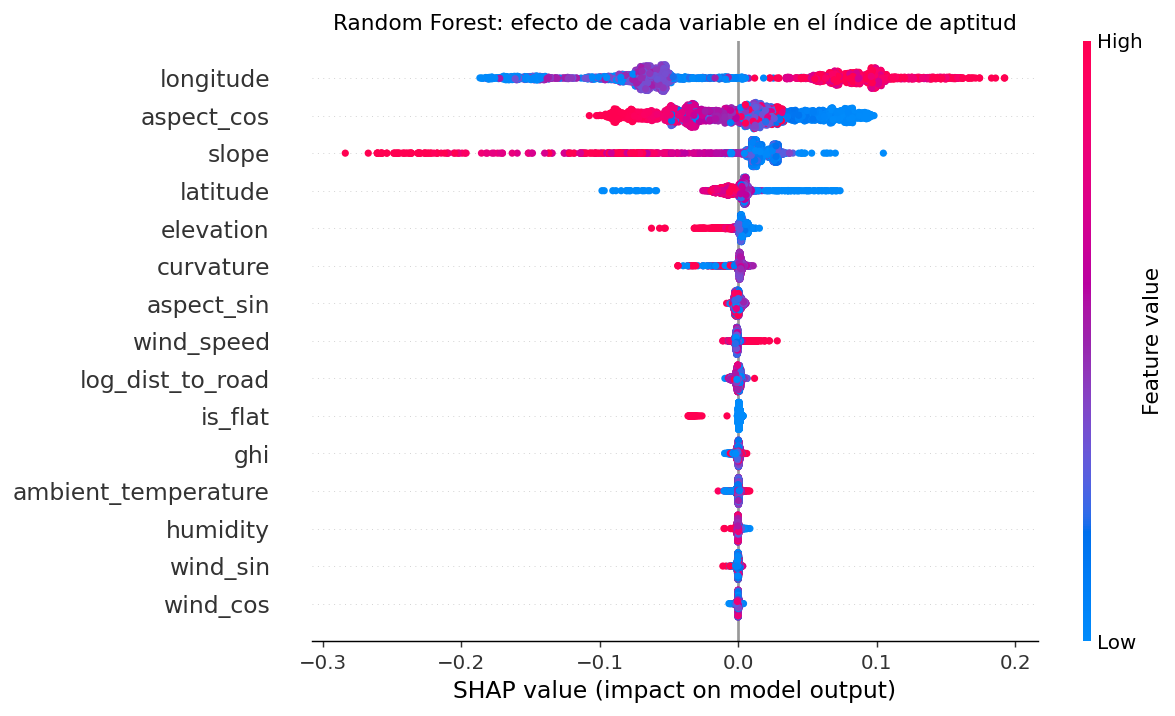

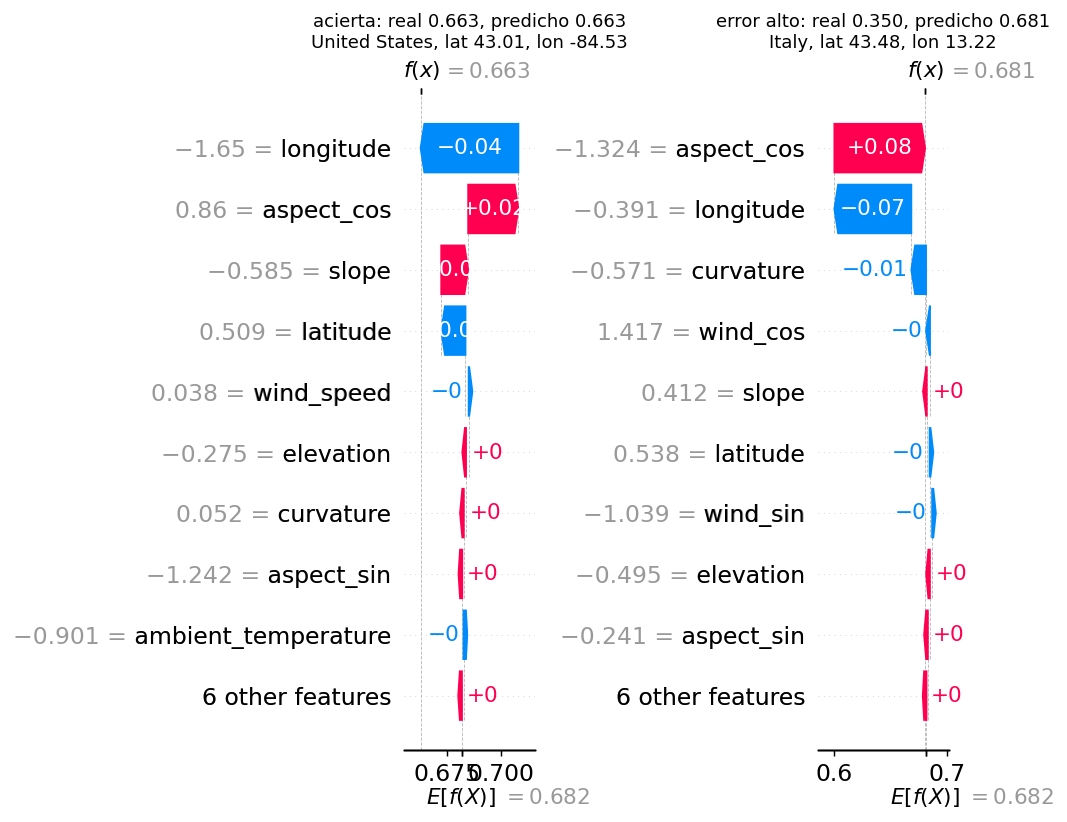

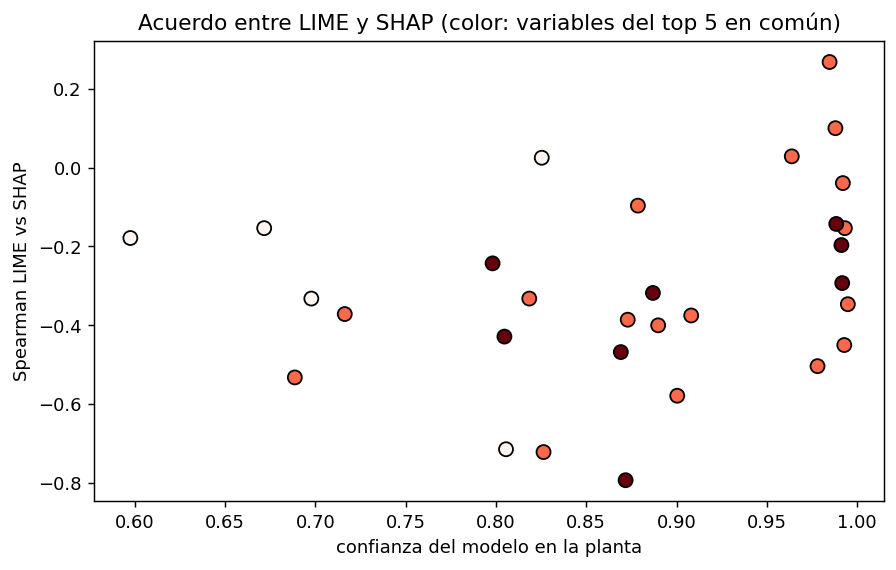

In [10]:
# Visualización de gráficos de interpretabilidad SHAP y LIME
if (PROCESO_DIR / "fig_exp_shap_clf.png").exists():
    display(Image(filename=str(PROCESO_DIR / "fig_exp_shap_clf.png"), width=720))
if (PROCESO_DIR / "fig_exp_shap_reg.png").exists():
    display(Image(filename=str(PROCESO_DIR / "fig_exp_shap_reg.png"), width=720))
if (PROCESO_DIR / "fig_exp_shap_cascada.png").exists():
    display(Image(filename=str(PROCESO_DIR / "fig_exp_shap_cascada.png"), width=720))
if (PROCESO_DIR / "fig_exp_lime_shap.png").exists():
    display(Image(filename=str(PROCESO_DIR / "fig_exp_lime_shap.png"), width=720))

## 10. De la auditoría del dataset a la generación real en Colombia

El índice de Mantilla-Guerra et al. (2026) no incluye variables de clima (GHI, temperatura, nubosidad) en su fórmula. Su correlación de Spearman con la longitud es de 0.58, y el 94.5 % de la clase Baja viene de un lote europeo. Con leave-one-region-out, el R² es negativo en todos los modelos.

La base de Colombia reúne 16 plantas solares (2024 a 2026, 8,589 días planta) con la generación diaria de XM y el clima de Open-Meteo. El clima explica una mediana de R² de 0.47 de la variación diaria del factor de capacidad, y casi todo viene de la radiación. Con datos reales los modelos lineales rinden igual que los complejos, porque la energía que entrega la planta es casi proporcional a la radiación que recibe.

Siguen pendientes la tecnología de cada planta (seguidor o fija, potencia DC frente a AC), la radiación medida en estaciones y los datos horarios con un índice de claridad.

## Referencias

- Cawley, G. C. y Talbot, N. L. C. (2010). On over-fitting in model selection and subsequent selection bias in performance evaluation. *Journal of Machine Learning Research, 11*, 2079-2107.
- DeLong, E. R., DeLong, D. M. y Clarke-Pearson, D. L. (1988). Comparing the areas under two or more correlated receiver operating characteristic curves: A nonparametric approach. *Biometrics, 44*(3), 837-845. https://doi.org/10.2307/2531595
- Demšar, J. (2006). Statistical comparisons of classifiers over multiple data sets. *Journal of Machine Learning Research, 7*, 1-30.
- Diebold, F. X. y Mariano, R. S. (1995). Comparing predictive accuracy. *Journal of Business & Economic Statistics, 13*(3), 253-263. https://doi.org/10.1080/07350015.1995.10524599
- Hansen, P. R., Lunde, A. y Nason, J. M. (2011). The model confidence set. *Econometrica, 79*(2), 453-497. https://doi.org/10.3982/ECTA5771
- Lundberg, S. M., Erion, G., Chen, H., DeGrave, A., Prutkin, J. M., Nair, B., Katz, R., Himmelfarb, J., Bansal, N. y Lee, S.-I. (2020). From local explanations to global understanding with explainable AI for trees. *Nature Machine Intelligence, 2*, 56-67. https://doi.org/10.1038/s42256-019-0138-9
- Mantilla-Guerra, A., Mejia-Escobar, C., Azorin-Lopez, J. y Garcia-Rodriguez, J. (2026). Global dataset of solar power plants: multidimensional integration and analysis. *Eng, 7*(7), 343. https://doi.org/10.3390/eng7070343
- Ribeiro, M. T., Singh, S. y Guestrin, C. (2016). "Why should I trust you?": Explaining the predictions of any classifier. En *Proceedings of the 22nd ACM SIGKDD* (pp. 1135-1144). https://doi.org/10.1145/2939672.2939778
- Roberts, D. R. et al. (2017). Cross-validation strategies for data with temporal, spatial, hierarchical, or phylogenetic structure. *Ecography, 40*(8), 913-929. https://doi.org/10.1111/ecog.02881